<a href="https://colab.research.google.com/github/seoyoungleeme/finops-cost-anomaly-benchmark/blob/main/FinOps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 클라우드 비용 시계열 이상 탐지 — 비용 가중 평가 프레임워크

## Part 1. 합성 데이터 생성, 이상 주입, 시각화

본 노트북은 4가지 이상 탐지 패러다임(EWMA, IsolationForest, LSTM AE, Prophet)을
point-wise / event-level / cost-weighted metric으로 비교한다.

## 0. 패키지 설치 및 import

In [ ]:
# Colab에서 위에서 아래로 실행 가능하게 전체 노트북에서 필요한 패키지를 한 번에 설치한다.
# Part 2 이후에서 사용할 prophet은 Colab 기본환경에 없으므로 미리 설치한다.
!pip install -q prophet

import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# 출력 폴더 준비 (csv, figure 저장용)
OUTPUT_DIR = "./outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)

numpy: 2.0.2
pandas: 2.2.2


## 1. 전역 설정

- 730일(2년) 일별 시계열
- Year 1 (day 0~364): 정상 학습 구간
- Year 2 (day 365~729): 이상 주입 + 평가 구간
- 모든 무작위성은 seed로 통제한다

In [ ]:
# 전역 설정 상수.
# 모든 함수는 이 값들을 인자로 받아 사용한다 (전역 의존을 줄이기 위함).

RANDOM_SEED = 42

N_DAYS = 730                # 총 길이 (일)
YEAR2_START = 365           # 평가 구간 시작 day index
BASE_LEVEL = 1000.0         # 기준 일 비용 (달러)
MONTHLY_GROWTH = 0.015      # 월 1.5% 선형 증가
NOISE_PCT = 0.05            # baseline 대비 5% Gaussian noise
START_DATE = "2024-01-01"   # 2024-01-01은 월요일이라 dow=t%7로 0=Mon이 자연스럽다

# 이상 강도 정의 (각 유형마다 의미 다름)
SPIKE_LEVELS = {"low": 0.30, "mid": 1.00, "high": 3.00}        # baseline 대비 +pct
CONTEXTUAL_LEVELS = {"low": 0.50, "mid": 1.00, "high": 2.00}   # 주말 baseline 대비 +pct
GRADUAL_LEVELS = {"low": 0.03, "mid": 0.05, "high": 0.10}      # 일일 누적 +pct

# 이벤트 주입 횟수 (각 type x intensity 조합당)
N_EVENTS_LOW = 3
N_EVENTS_HIGH = 6  # exclusive upper bound -> 결과 3,4,5

# DataFrame 표준 컬럼 (모델별 score 인터페이스 통일을 위해 고정)
DF_COLUMNS = [
    "date", "day", "y", "y_expected_baseline",
    "is_anomaly", "anomaly_type", "intensity_level", "event_id",
    "excess_cost", "score", "alert",
]

print("Config loaded.")

Config loaded.


## 2. 합성 정상 비용 시계열 생성

y(t) = trend(t) + weekly_seasonality(t) + monthly_seasonality(t) + noise(t)

- trend: 월 1.5% 선형 증가
- weekly_seasonality: 주중 약간 높고 주말 낮음 (평균 1.0이 되도록 정규화)
- monthly_seasonality: 월말 3일 +5% 배치 효과
- noise: baseline 대비 5% Gaussian
- y_expected_baseline은 noise를 제외한 ground-truth 기대값

In [ ]:
def generate_baseline_series(
    n_days=N_DAYS,
    base_level=BASE_LEVEL,
    monthly_growth=MONTHLY_GROWTH,
    noise_pct=NOISE_PCT,
    start_date=START_DATE,
    seed=RANDOM_SEED,
):
    """
    정상 패턴 시계열을 생성한다.

    구성요소
        trend                : 월 monthly_growth 만큼 선형 증가 (일 단위 환산)
        weekly_seasonality   : 주중 높고 주말 낮은 곱셈형 패턴
        monthly_seasonality  : 월말 3일에 +5% 배치 효과
        noise                : 기대값 대비 noise_pct 비율의 Gaussian noise

    Parameters
    ----------
    n_days        : 총 일수
    base_level    : day=0 시점의 기본 비용 수준
    monthly_growth: 월별 추세 증가율 (e.g. 0.015 == 1.5%)
    noise_pct     : 기대값 대비 노이즈 표준편차 비율
    start_date    : 시계열 시작 일자 (string)
    seed          : 재현성용 난수 시드

    Returns
    -------
    y_actual    : (n_days,) 노이즈가 포함된 실제 관측 비용
    y_expected  : (n_days,) 노이즈를 제외한 기대값 (이상 주입 전 ground-truth baseline)
    dates       : pandas DatetimeIndex
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n_days)
    dates = pd.date_range(start=start_date, periods=n_days, freq="D")

    # 1) 추세: 월 monthly_growth -> 일 단위로 환산
    daily_growth = monthly_growth / 30.0
    trend = base_level * (1.0 + daily_growth * t)

    # 2) 주간 계절성: 0=Mon, ..., 6=Sun, 평균 1.0이 되도록 설계
    dow = t % 7
    weekly_factor = np.array([1.10, 1.15, 1.15, 1.15, 1.05, 0.75, 0.65])
    weekly = trend * (weekly_factor[dow] - 1.0)

    # 3) 월말 배치 효과: 실제 달력 기준으로 일 28일 이상이면 +5%
    dom = dates.day.values
    monthly = np.where(dom >= 28, trend * 0.05, 0.0)

    # 노이즈 제외 기대값
    y_expected = trend + weekly + monthly

    # 4) Gaussian noise (기대값 대비 noise_pct 비율)
    noise = rng.normal(0.0, noise_pct, n_days) * y_expected
    y_actual = y_expected + noise

    return y_actual, y_expected, dates


# 동작 확인
_y, _yb, _d = generate_baseline_series(seed=RANDOM_SEED)
print("y_actual   shape:", _y.shape, "mean:", round(_y.mean(), 2))
print("y_expected shape:", _yb.shape, "mean:", round(_yb.mean(), 2))
print("dates range:", _d.min().date(), "->", _d.max().date())

y_actual   shape: (730,) mean: 1186.79
y_expected shape: (730,) mean: 1189.23
dates range: 2024-01-01 -> 2025-12-30


## 3. spike / contextual / gradual anomaly 주입

- spike      : 1~2일 급격 증가, baseline 대비 +30% / +100% / +300%
- contextual : 주말에 주중 수준 비용, 주말 baseline 대비 +50% / +100% / +200%
- gradual    : 7~14일 ramp-up, 일일 누적 +3% / +5% / +10%

이벤트는 Year 2 구간에만 주입하고, 서로 겹치지 않게 한다.
각 유형 × 강도 조합당 3~5회 주입.

In [ ]:
def inject_anomalies(
    y_actual,
    y_expected,
    year2_start=YEAR2_START,
    spike_levels=SPIKE_LEVELS,
    contextual_levels=CONTEXTUAL_LEVELS,
    gradual_levels=GRADUAL_LEVELS,
    n_events_low=N_EVENTS_LOW,
    n_events_high=N_EVENTS_HIGH,
    seed=RANDOM_SEED,
):
    """
    Year 2 구간에 spike / contextual / gradual 이상을 주입한다.

    이벤트 규칙
        - 모든 이벤트는 Year 2 (day >= year2_start) 안에만 위치한다.
        - 이벤트끼리 서로 겹치지 않는다 (양쪽 buffer 포함).
        - 각 (anomaly_type, intensity_level) 조합당 n_events_low~n_events_high 회 주입.
        - 슬롯 탐색 실패 시 해당 시도는 건너뛴다.

    Parameters
    ----------
    y_actual          : (n,) 노이즈 포함 정상 시계열
    y_expected        : (n,) 노이즈 제외 ground-truth baseline
    year2_start       : Year 2 시작 day index
    spike_levels      : {"low": 0.30, "mid": 1.00, "high": 3.00}
    contextual_levels : {"low": 0.50, "mid": 1.00, "high": 2.00}
    gradual_levels    : {"low": 0.03, "mid": 0.05, "high": 0.10}
    seed              : 재현성용 난수 시드

    Returns
    -------
    y_modified     : (n,) 이상 주입 후 시계열
    excess_cost    : (n,) y_modified - y_expected
    is_anomaly     : (n,) bool
    anomaly_type   : (n,) object, {"none","spike","contextual","gradual"}
    intensity_level: (n,) object, {"none","low","mid","high"}
    event_id_arr   : (n,) int (정상=0, 이상이면 1부터)
    events_df      : 이벤트 메타 DataFrame
                     [event_id, anomaly_type, intensity_level,
                      start_day, end_day, total_excess_cost]
    """
    # 주입 단계의 난수는 baseline 생성 단계와 분리되도록 offset을 둔다.
    rng = np.random.default_rng(seed + 10_000)
    n = len(y_actual)

    y_modified = y_actual.copy()
    is_anomaly = np.zeros(n, dtype=bool)
    anomaly_type = np.array(["none"] * n, dtype=object)
    intensity_level = np.array(["none"] * n, dtype=object)
    event_id_arr = np.zeros(n, dtype=np.int64)
    injected_cost = np.zeros(n, dtype=float)

    # 이미 점유된 day 표시. Year 1 전체는 보호.
    occupied = np.zeros(n, dtype=bool)
    occupied[:year2_start] = True

    events = []
    next_event_id = 1

    def _find_slot(length, buffer, weekend_start=False, max_tries=300):
        """
        Year 2 구간에서 길이 length짜리 비점유 슬롯을 찾는다.
        weekend_start=True면 토요일에서 시작 (dow == 5).
        """
        for _ in range(max_tries):
            start = int(rng.integers(year2_start, n - length - buffer))
            if weekend_start and (start % 7) != 5:
                continue
            lo = max(0, start - buffer)
            hi = min(n, start + length + buffer)
            if not occupied[lo:hi].any():
                return start
        return None

    def _mark_occupied(start, length, buffer):
        """슬롯을 점유 처리 (양쪽 buffer 포함)."""
        lo = max(0, start - buffer)
        hi = min(n, start + length + buffer)
        occupied[lo:hi] = True

    # ---------- 1) Spike ----------
    # 1~2일 급격 증가. baseline 대비 +mult.
    for level, mult in spike_levels.items():
        n_inject = int(rng.integers(n_events_low, n_events_high))
        for _ in range(n_inject):
            length = int(rng.integers(1, 3))     # 1 또는 2일
            start = _find_slot(length, buffer=2)
            if start is None:
                continue
            for k in range(length):
                idx = start + k
                add = y_expected[idx] * mult
                y_modified[idx] = y_actual[idx] + add
                injected_cost[idx] = add
                is_anomaly[idx] = True
                anomaly_type[idx] = "spike"
                intensity_level[idx] = level
                event_id_arr[idx] = next_event_id
            _mark_occupied(start, length, buffer=2)
            events.append({
                "event_id": next_event_id,
                "anomaly_type": "spike",
                "intensity_level": level,
                "start_day": start,
                "end_day": start + length - 1,
            })
            next_event_id += 1

    # ---------- 2) Contextual ----------
    # 주말에 주중 수준 비용. 주말 baseline 대비 +mult.
    # 토요일에서 시작, 길이 1 또는 2 (Sat 또는 Sat+Sun).
    for level, mult in contextual_levels.items():
        n_inject = int(rng.integers(n_events_low, n_events_high))
        for _ in range(n_inject):
            length = int(rng.integers(1, 3))
            start = _find_slot(length, buffer=2, weekend_start=True)
            if start is None:
                continue
            for k in range(length):
                idx = start + k
                add = y_expected[idx] * mult
                y_modified[idx] = y_actual[idx] + add
                injected_cost[idx] = add
                is_anomaly[idx] = True
                anomaly_type[idx] = "contextual"
                intensity_level[idx] = level
                event_id_arr[idx] = next_event_id
            _mark_occupied(start, length, buffer=2)
            events.append({
                "event_id": next_event_id,
                "anomaly_type": "contextual",
                "intensity_level": level,
                "start_day": start,
                "end_day": start + length - 1,
            })
            next_event_id += 1

    # ---------- 3) Gradual ----------
    # 7~14일 동안 일일 누적 +daily_pct. day k 시점 추가량 = baseline * daily_pct * (k+1).
    for level, daily_pct in gradual_levels.items():
        n_inject = int(rng.integers(n_events_low, n_events_high))
        for _ in range(n_inject):
            length = int(rng.integers(7, 15))    # 7~14일
            start = _find_slot(length, buffer=3)
            if start is None:
                continue
            for k in range(length):
                idx = start + k
                add = y_expected[idx] * daily_pct * (k + 1)
                y_modified[idx] = y_actual[idx] + add
                injected_cost[idx] = add
                is_anomaly[idx] = True
                anomaly_type[idx] = "gradual"
                intensity_level[idx] = level
                event_id_arr[idx] = next_event_id
            _mark_occupied(start, length, buffer=3)
            events.append({
                "event_id": next_event_id,
                "anomaly_type": "gradual",
                "intensity_level": level,
                "start_day": start,
                "end_day": start + length - 1,
            })
            next_event_id += 1

    # ---------- excess_cost / event total ----------
    # observed residual: 관측-기대값 (noise 포함, 호환성 위해 유지)
    excess_cost = y_modified - y_expected
    # ground-truth cost impact: 합성 시 주입한 정확한 비용. 정상 구간은 0.
    cost_impact = injected_cost.copy()

    for ev in events:
        s, e = ev["start_day"], ev["end_day"]
        ev["total_excess_cost"] = float(cost_impact[s:e + 1].sum())

    events_df = (
        pd.DataFrame(events)
        .sort_values("start_day")
        .reset_index(drop=True)
    )

    return (
    y_modified, excess_cost, cost_impact,
    is_anomaly, anomaly_type, intensity_level, event_id_arr,
    events_df,
    )

## 4. excess_cost 및 event label 생성 — 통합 DataFrame 구성

표준 컬럼:
date, day, y, y_expected_baseline, is_anomaly, anomaly_type, intensity_level,
event_id, excess_cost, score, alert

In [ ]:
def build_dataset(seed=RANDOM_SEED, n_days=N_DAYS, year2_start=YEAR2_START,
                  start_date=START_DATE):
    """
    합성 데이터셋 한 벌(시계열 + event table)을 생성하여 표준 형태로 반환한다.

    Parameters
    ----------
    seed       : 재현성용 시드 (baseline + 이상 주입 둘 다 통제)
    n_days     : 총 일수
    year2_start: Year 2 시작 day index
    start_date : 시계열 시작 일자

    Returns
    -------
    df         : pandas.DataFrame (n_days rows, 표준 컬럼)
    events_df  : pandas.DataFrame (이벤트 단위 메타)
    """
    # 1) 정상 시계열
    y_actual, y_expected, dates = generate_baseline_series(
        n_days=n_days, start_date=start_date, seed=seed,
    )

    # 2) 이상 주입
    (y_mod, excess, cost_imp, is_anom, a_type, a_int, ev_id, events_df) = inject_anomalies(
    y_actual, y_expected,
    year2_start=year2_start,
    seed=seed,
    )

    # 3) 표준 DataFrame 구성
    df = pd.DataFrame({
    "date": dates,
    "day": np.arange(n_days),
    "y": y_mod,
    "y_expected_baseline": y_expected,
    "is_anomaly": is_anom,
    "anomaly_type": a_type,
    "intensity_level": a_int,
    "event_id": ev_id,
    "excess_cost": excess,           # observed residual (호환성용, 진단/시각화에 사용)
    "cost_impact": cost_imp,         # ground-truth 주입 비용 (평가의 진짜 기준)
    })
    df["score"] = np.nan
    df["alert"] = False
    # DF_COLUMNS는 Cell 5에 정의되어 있음. 아래 한 줄로 동적 확장.
    extended_cols = list(DF_COLUMNS)
    if "cost_impact" not in extended_cols:
        insert_at = extended_cols.index("excess_cost") + 1
        extended_cols.insert(insert_at, "cost_impact")
    df = df[extended_cols]

    return df, events_df


# 단일 seed로 데이터셋 생성 (Part 1 sanity check)
df, events_df = build_dataset(seed=RANDOM_SEED)

print("=== df head ===")
print(df.head())
print("\n=== df shape ===", df.shape)
print("\n=== anomaly day count ===")
print(df.groupby(["anomaly_type", "intensity_level"]).size())
print("\n=== events_df ===")
print(events_df)
print("\n=== events_df summary ===")
print(events_df.groupby(["anomaly_type", "intensity_level"]).agg(
    n_events=("event_id", "count"),
    mean_total_excess=("total_excess_cost", "mean"),
    sum_total_excess=("total_excess_cost", "sum"),
).round(2))

=== df head ===
        date  day            y  y_expected_baseline  is_anomaly anomaly_type  \
0 2024-01-01    0  1116.759439             1100.000       False         none   
1 2024-01-02    1  1090.746014             1150.575       False         none   
2 2024-01-03    2  1194.344095             1151.150       False         none   
3 2024-01-04    3  1205.888595             1151.725       False         none   
4 2024-01-05    4   949.465794             1052.100       False         none   

  intensity_level  event_id  excess_cost  cost_impact  score  alert  
0            none         0    16.759439          0.0    NaN  False  
1            none         0   -59.828986          0.0    NaN  False  
2            none         0    43.194095          0.0    NaN  False  
3            none         0    54.163595          0.0    NaN  False  
4            none         0  -102.634206          0.0    NaN  False  

=== df shape === (730, 12)

=== anomaly day count ===
anomaly_type  intensity_leve

## 5. 데이터 시각화

- 상단: 전체 시계열 + expected baseline + 이상 점 색상별 표시
- 하단: excess_cost (이상 구간 음영)
- 하단 보조: 이상 유형별 zoom-in 예시

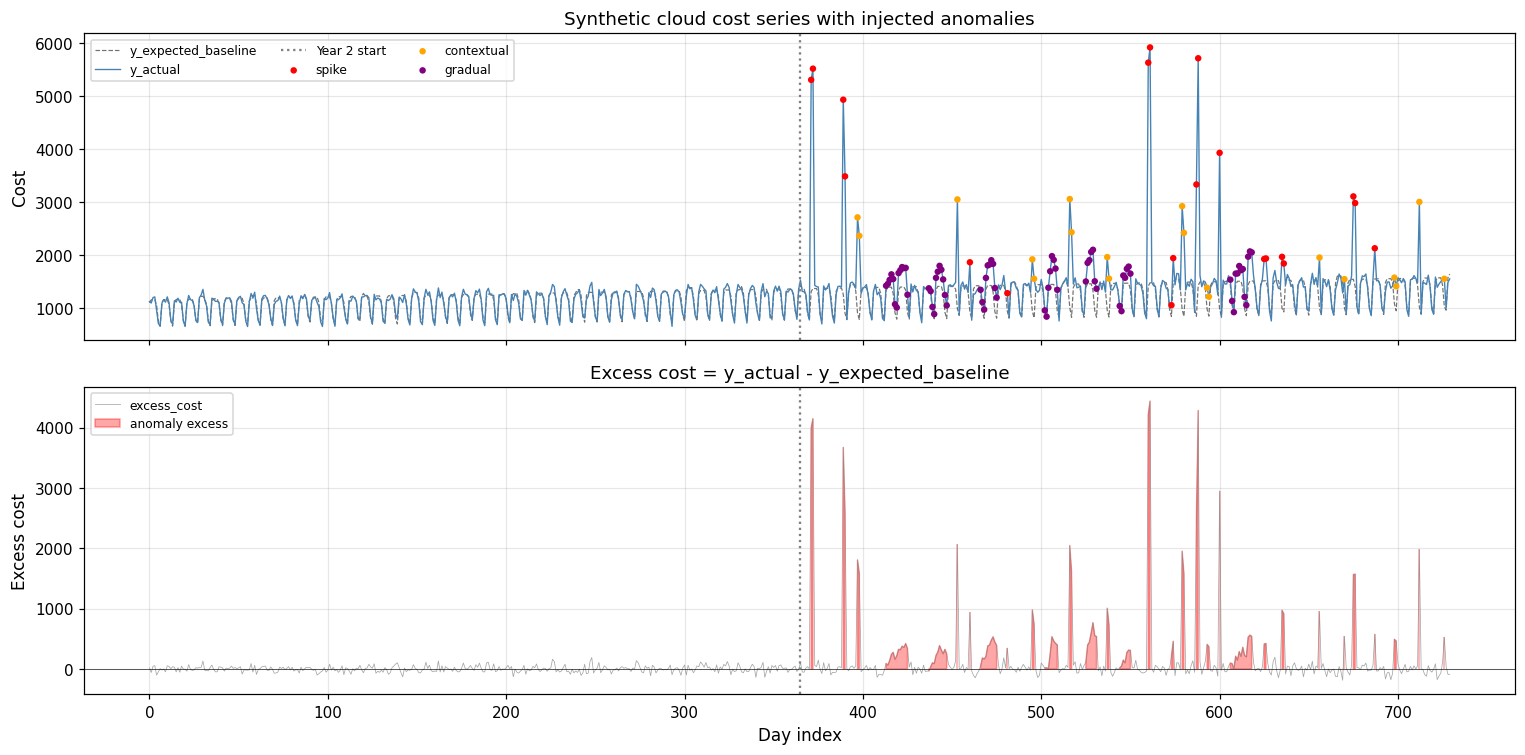

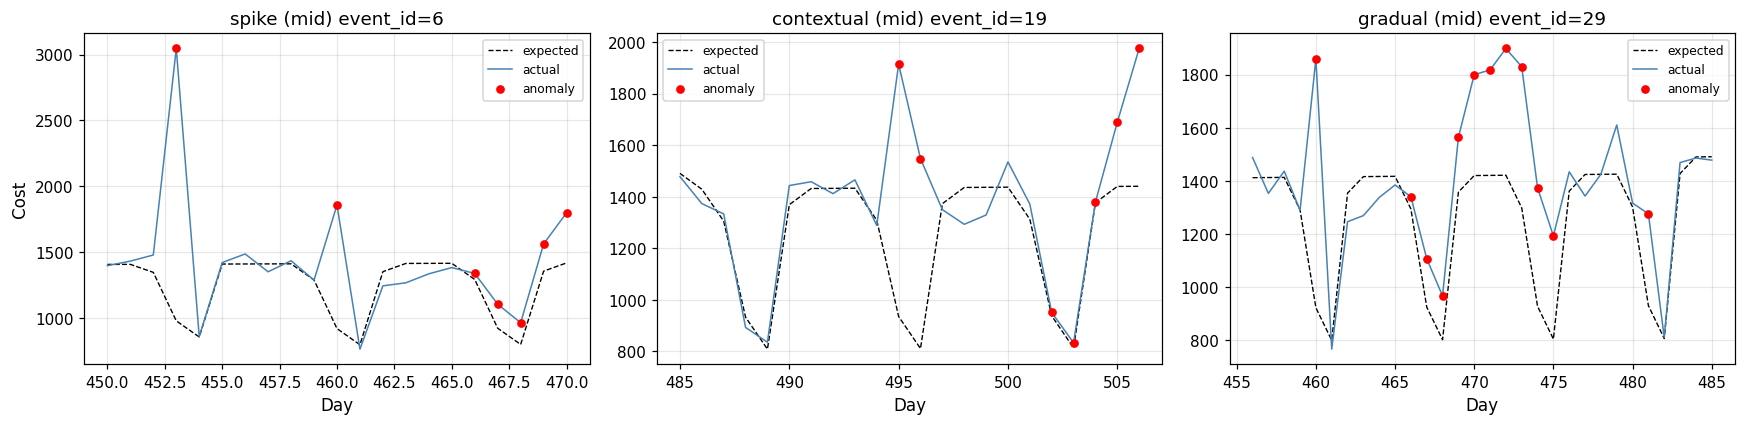

In [ ]:
def plot_data_overview(df, events_df, year2_start=YEAR2_START, save_path=None):
    """
    전체 시계열과 excess_cost를 한 figure에 시각화한다.
    이상 점은 anomaly_type별 색상으로 구분한다.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    ax0 = axes[0]
    ax0.plot(df["day"], df["y_expected_baseline"],
             color="black", lw=0.8, ls="--", alpha=0.55,
             label="y_expected_baseline")
    ax0.plot(df["day"], df["y"],
             color="steelblue", lw=0.9, label="y_actual")
    ax0.axvline(year2_start, color="gray", ls=":", label="Year 2 start")

    color_map = {"spike": "red", "contextual": "orange", "gradual": "purple"}
    for atype, c in color_map.items():
        m = (df["anomaly_type"] == atype)
        if m.any():
            ax0.scatter(df.loc[m, "day"], df.loc[m, "y"],
                        s=18, color=c, label=atype,
                        zorder=5, edgecolors="none")

    ax0.set_title("Synthetic cloud cost series with injected anomalies")
    ax0.set_ylabel("Cost")
    ax0.legend(loc="upper left", fontsize=8, ncol=3)
    ax0.grid(alpha=0.3)

    ax1 = axes[1]
    ax1.plot(df["day"], df["excess_cost"],
             color="gray", lw=0.5, alpha=0.7, label="excess_cost")
    ax1.fill_between(df["day"], 0, df["excess_cost"],
                     where=df["is_anomaly"].values,
                     color="red", alpha=0.35,
                     label="anomaly excess")
    ax1.axhline(0, color="black", lw=0.4)
    ax1.axvline(year2_start, color="gray", ls=":")
    ax1.set_xlabel("Day index")
    ax1.set_ylabel("Excess cost")
    ax1.set_title("Excess cost = y_actual - y_expected_baseline")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(alpha=0.3)

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    return fig


def plot_anomaly_examples(df, events_df, save_path=None, window=10):
    """
    각 anomaly_type별로 한 개 예시 이벤트를 골라 zoom-in 시각화한다.
    이벤트 앞뒤 window 일을 함께 표시.
    """
    types = ["spike", "contextual", "gradual"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, atype in zip(axes, types):
        sub = events_df[events_df["anomaly_type"] == atype]
        if len(sub) == 0:
            ax.set_title(f"{atype} (no event)")
            continue

        cand = sub[sub["intensity_level"] == "mid"]
        ev = (cand.iloc[0] if len(cand) else sub.iloc[0])

        s = max(0, int(ev["start_day"]) - window)
        e = min(len(df), int(ev["end_day"]) + window + 1)
        seg = df.iloc[s:e]

        ax.plot(seg["day"], seg["y_expected_baseline"],
                color="black", ls="--", lw=0.9, label="expected")
        ax.plot(seg["day"], seg["y"],
                color="steelblue", lw=1.0, label="actual")

        m = seg["is_anomaly"]
        ax.scatter(seg.loc[m, "day"], seg.loc[m, "y"],
                   s=22, color="red", zorder=5, label="anomaly")

        ax.set_title(f"{atype} ({ev['intensity_level']}) "
                     f"event_id={int(ev['event_id'])}")
        ax.set_xlabel("Day")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Cost")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    return fig


# 시각화 실행
_ = plot_data_overview(
    df, events_df,
    save_path=os.path.join(FIG_DIR, "01_data_overview.png"),
)
plt.show()

_ = plot_anomaly_examples(
    df, events_df,
    save_path=os.path.join(FIG_DIR, "02_anomaly_examples.png"),
)
plt.show()

## 6. 모델별 anomaly score 계산

공통 인터페이스

- 모든 모델은 Year 1 (day < year2_start) 구간만 학습/적합에 사용한다.
- 점수는 항상 730일 전체에 대해 산출하고, 산출 불가 구간은 NaN을 둔다.
- score는 "클수록 이상"이 되도록 부호를 통일한다 (절댓값/부호 반전).

### 6-1. EWMA + rolling-std z-score

- baseline: span=14의 EWMA
- residual = y - EWMA
- rolling_std: 30일 이동 표준편차
- z = residual / rolling_std
- score = |z|

EWMA와 rolling_std 모두 과거값 기반이라 전체 시계열에 적용 가능하지만,
공정성을 위해 rolling_std는 Year 1 자료만 사용해 정상 변동성 척도를 만들고,
Year 1과 Year 2 모두 동일한 rolling 규칙으로 평가한다.

In [ ]:
def score_with_ewma(df, events_df=None, seed=RANDOM_SEED,
                    year2_start=YEAR2_START,
                    span=14, std_window=30, eps=1e-6):
    """
    EWMA + rolling-std 기반 z-score.

    절차
        1. y에 대해 span=14 EWMA를 적용해 동적 baseline mu_t를 구한다.
        2. residual_t = y_t - mu_t.
        3. residual의 rolling std (window=std_window)을 표준편차로 사용한다.
        4. z_t = residual_t / sigma_t.
        5. score_t = |z_t|.

    Parameters
    ----------
    df          : 표준 DataFrame (Cell 11에서 생성)
    events_df   : 사용하지 않음 (인터페이스 통일을 위해 인자만 유지)
    seed        : 재현성용 (EWMA 자체는 결정론이라 사용 안 함)
    year2_start : Year 2 시작 day index
    span        : EWMA span (반응성 ↔ 평활성 트레이드오프)
    std_window  : residual rolling 표준편차 윈도우 길이
    eps         : 0 분모 방지용 작은 수

    Returns
    -------
    DataFrame [model_name, date, day, score]
    """
    y = df["y"].values.astype(float)

    # 1) EWMA baseline (adjust=False가 일반적인 EW 평활)
    s_y = pd.Series(y)
    mu = s_y.ewm(span=span, adjust=False).mean().values

    # 2) residual
    residual = y - mu

    # 3) rolling std는 Year 1의 residual로 학습한 뒤
    #    동일 규칙(rolling)을 전 구간에 적용해 동적 sigma_t를 만든다.
    res_series = pd.Series(residual)
    sigma_t = res_series.rolling(window=std_window, min_periods=std_window).std().values

    # rolling이 충족 안 되는 초반 구간은 Year 1 residual의 전체 std로 대체한다
    # (점수 계산 자체는 가능하게 두되, 워밍업 영향은 평가 시 자연 흡수됨).
    year1_residual = residual[:year2_start]
    fallback_std = float(np.nanstd(year1_residual))
    sigma_t = np.where(np.isnan(sigma_t), fallback_std, sigma_t)
    sigma_t = np.where(sigma_t < eps, eps, sigma_t)

    # 4) z-score
    z = residual / sigma_t
    score = np.abs(z)

    out = pd.DataFrame({
        "model_name": "EWMA",
        "date": df["date"].values,
        "day": df["day"].values,
        "score": score,
    })
    return out


# sanity check
ewma_scores = score_with_ewma(df)
print(ewma_scores.head())
print("EWMA score stats:", ewma_scores["score"].describe().round(3).to_dict())

  model_name       date  day     score
0       EWMA 2024-01-01    0  0.000000
1       EWMA 2024-01-02    1  0.111314
2       EWMA 2024-01-03    2  0.346833
3       EWMA 2024-01-04    3  0.349989
4       EWMA 2024-01-05    4  0.793932
EWMA score stats: {'count': 730.0, 'mean': 0.763, 'std': 0.627, 'min': 0.0, '25%': 0.303, '50%': 0.642, '75%': 1.107, 'max': 5.189}


### 6-2. Isolation Forest

피처
- y_norm        : Year 1 평균/표준편차로 표준화한 y
- dow_sin/cos   : 요일 주기
- dom_sin/cos   : 월중일 주기
- lag1_ratio    : y_t / y_{t-1}
- lag7_ratio    : y_t / y_{t-7}

학습은 Year 1만 사용. score = -decision_function (클수록 이상).

In [ ]:
def _build_if_features(df, year2_start=YEAR2_START):
    """
    Isolation Forest용 피처 행렬을 구성한다.

    Returns
    -------
    X         : (n, k) ndarray (NaN 가능 → 사용 시 마스크)
    valid_idx : (n,) bool, 모든 피처가 유효한 행 표시
    feat_cols : 피처 이름 리스트
    """
    y = df["y"].values.astype(float)
    dates = pd.to_datetime(df["date"].values)
    n = len(y)

    # Year 1 통계로 정규화 (Year 2 정보 누수 방지)
    mu1 = float(np.mean(y[:year2_start]))
    sd1 = float(np.std(y[:year2_start]) + 1e-6)
    y_norm = (y - mu1) / sd1

    dow = pd.Series(dates).dt.dayofweek.values
    dom = pd.Series(dates).dt.day.values
    dow_sin = np.sin(2 * np.pi * dow / 7.0)
    dow_cos = np.cos(2 * np.pi * dow / 7.0)
    dom_sin = np.sin(2 * np.pi * dom / 31.0)
    dom_cos = np.cos(2 * np.pi * dom / 31.0)

    # 안전한 lag ratio (분모가 0 근처면 NaN 처리)
    def _safe_ratio(num, den):
        out = np.full_like(num, np.nan, dtype=float)
        mask = np.abs(den) > 1e-6
        out[mask] = num[mask] / den[mask]
        return out

    lag1 = np.roll(y, 1); lag1[:1] = np.nan
    lag7 = np.roll(y, 7); lag7[:7] = np.nan
    lag1_ratio = _safe_ratio(y, lag1)
    lag7_ratio = _safe_ratio(y, lag7)

    X = np.column_stack([
        y_norm, dow_sin, dow_cos, dom_sin, dom_cos, lag1_ratio, lag7_ratio,
    ])
    feat_cols = ["y_norm", "dow_sin", "dow_cos", "dom_sin", "dom_cos",
                 "lag1_ratio", "lag7_ratio"]
    valid_idx = ~np.isnan(X).any(axis=1)
    return X, valid_idx, feat_cols


def score_with_iforest(df, events_df=None, seed=RANDOM_SEED,
                       year2_start=YEAR2_START,
                       n_estimators=200, contamination="auto"):
    """
    Isolation Forest 기반 anomaly score.

    절차
        1. 피처 구성 (Year 1 통계로 정규화).
        2. Year 1의 valid 행만으로 IsolationForest를 학습.
        3. 전체 valid 행에 대해 -decision_function을 score로 둔다 (클수록 이상).
        4. invalid 행(워밍업)은 score=NaN.

    Parameters
    ----------
    df             : 표준 DataFrame
    events_df      : 사용하지 않음
    seed           : random_state
    year2_start    : Year 2 시작 day index
    n_estimators   : 트리 수
    contamination  : sklearn 옵션 ("auto" 또는 0~0.5 부동소수)

    Returns
    -------
    DataFrame [model_name, date, day, score]
    """
    from sklearn.ensemble import IsolationForest

    n = len(df)
    X, valid_idx, _ = _build_if_features(df, year2_start=year2_start)

    # Year 1 train set: valid 행 중 day < year2_start
    days = df["day"].values
    train_mask = valid_idx & (days < year2_start)

    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=seed,
        n_jobs=-1,
    )
    model.fit(X[train_mask])

    # 전 구간 점수: -decision_function이 클수록 이상
    score = np.full(n, np.nan, dtype=float)
    if valid_idx.any():
        score[valid_idx] = -model.decision_function(X[valid_idx])

    out = pd.DataFrame({
        "model_name": "IsolationForest",
        "date": df["date"].values,
        "day": df["day"].values,
        "score": score,
    })
    return out


# sanity check
if_scores = score_with_iforest(df, seed=RANDOM_SEED)
print(if_scores.head())
print("IF score stats:", if_scores["score"].describe().round(3).to_dict())

        model_name       date  day  score
0  IsolationForest 2024-01-01    0    NaN
1  IsolationForest 2024-01-02    1    NaN
2  IsolationForest 2024-01-03    2    NaN
3  IsolationForest 2024-01-04    3    NaN
4  IsolationForest 2024-01-05    4    NaN
IF score stats: {'count': 723.0, 'mean': 0.039, 'std': 0.043, 'min': -0.03, '25%': 0.006, '50%': 0.031, '75%': 0.068, 'max': 0.17}


### 6-3. Prophet residual

- Year 1 데이터로 Prophet 적합.
- Year 2 포함 전 구간 yhat / yhat_upper 예측.
- residual = y - yhat
- score = |residual| / sigma_year1, 여기서 sigma_year1은 Year 1 residual의 표준편차.

native threshold(Cell 9-4)는 Part 3에서 yhat_upper(interval_width=0.99) 초과로 정의하므로,
score 산출 단계에선 prophet의 yhat과 yhat_upper를 함께 보존한다.

In [ ]:
def score_with_prophet(df, events_df=None, seed=RANDOM_SEED,
                       year2_start=YEAR2_START,
                       interval_width=0.99, eps=1e-6,
                       return_full=False):
    """
    Prophet 잔차 기반 anomaly score.

    절차
        1. Year 1 (day < year2_start) 데이터로 Prophet 적합.
        2. 전 구간 일자에 대해 yhat / yhat_upper 예측.
        3. residual = y - yhat.
        4. sigma_year1 = std(Year 1 residual).
        5. score = |residual| / sigma_year1.

    Parameters
    ----------
    df             : 표준 DataFrame
    events_df      : 사용하지 않음
    seed           : 재현성 (Prophet 내부 Stan 초기화에 직접 영향은 적지만 numpy 난수 통제용)
    year2_start    : Year 2 시작 day index
    interval_width : Prophet credible interval (native threshold용 보조 정보)
    eps            : 0 분모 방지
    return_full    : True면 (score_df, prophet_aux_df)를 함께 반환

    Returns
    -------
    DataFrame [model_name, date, day, score]
        return_full=True인 경우 (score_df, aux_df) 튜플.
        aux_df에는 yhat, yhat_upper가 포함되어 Part 3의 native threshold 실험에 사용된다.
    """
    # Prophet은 logging이 시끄러우므로 억제한다
    import logging
    logging.getLogger("prophet").setLevel(logging.ERROR)
    logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

    from prophet import Prophet
    np.random.seed(seed)

    # Prophet 입력 형식
    full = pd.DataFrame({
        "ds": pd.to_datetime(df["date"].values),
        "y":  df["y"].values.astype(float),
    })
    train = full.iloc[:year2_start].copy()

    m = Prophet(
        yearly_seasonality=False,   # 2년만 있어 연주기 학습은 불안정
        weekly_seasonality=True,
        daily_seasonality=False,
        interval_width=interval_width,
    )
    # 월말 배치 효과를 위한 추가 계절성
    m.add_seasonality(name="monthly", period=30.5, fourier_order=5)

    m.fit(train)

    forecast = m.predict(full[["ds"]])
    yhat = forecast["yhat"].values
    yhat_upper = forecast["yhat_upper"].values

    residual = full["y"].values - yhat
    sigma1 = float(np.std(residual[:year2_start]) + eps)
    score = np.abs(residual) / sigma1

    out = pd.DataFrame({
        "model_name": "Prophet",
        "date": df["date"].values,
        "day": df["day"].values,
        "score": score,
    })

    if return_full:
        aux = pd.DataFrame({
            "date": df["date"].values,
            "day": df["day"].values,
            "yhat": yhat,
            "yhat_upper": yhat_upper,
            "residual": residual,
        })
        return out, aux
    return out


# sanity check (시간이 좀 걸린다 — Stan 컴파일/적합)
prophet_scores, prophet_aux = score_with_prophet(df, seed=RANDOM_SEED, return_full=True)
print(prophet_scores.head())
print("Prophet score stats:", prophet_scores["score"].describe().round(3).to_dict())
print("aux columns:", prophet_aux.columns.tolist())

  model_name       date  day     score
0    Prophet 2024-01-01    0  0.074388
1    Prophet 2024-01-02    1  1.464514
2    Prophet 2024-01-03    2  0.397689
3    Prophet 2024-01-04    3  0.369344
4    Prophet 2024-01-05    4  1.803478
Prophet score stats: {'count': 730.0, 'mean': 2.914, 'std': 8.731, 'min': 0.005, '25%': 0.444, '50%': 0.968, '75%': 1.808, 'max': 84.478}
aux columns: ['date', 'day', 'yhat', 'yhat_upper', 'residual']


### 6-4. LSTM Autoencoder

- 입력: 길이 7 슬라이딩 윈도우의 (Year 1 통계로 정규화한) y
- 모델: encoder LSTM(hidden=16) → latent → decoder LSTM(hidden=16) → 재구성
- 손실: 윈도우 단위 MSE
- 학습: Year 1 윈도우만 사용
- score: 윈도우의 마지막 시점 t에 윈도우 MSE를 부여
- 전 구간에 대해 동일한 sliding window를 적용하여 score 산출
- 첫 (window-1)일은 NaN

In [ ]:
def score_with_lstm_ae(df, events_df=None, seed=RANDOM_SEED,
                       year2_start=YEAR2_START,
                       window_size=7, hidden_dim=16,
                       n_epochs=80, batch_size=32, lr=1e-2,
                       verbose=False):
    """
    LSTM Autoencoder 기반 anomaly score.

    절차
        1. y를 Year 1 평균/표준편차로 표준화한다.
        2. 길이 window_size의 sliding window를 만든다.
        3. encoder-decoder LSTM을 Year 1 윈도우(끝점 t < year2_start)로만 학습한다.
        4. 전체 윈도우에 대해 재구성 MSE를 계산하여,
           윈도우 마지막 시점 t에 score로 부여한다.
        5. 첫 (window_size - 1)일은 score=NaN.

    Parameters
    ----------
    df          : 표준 DataFrame
    events_df   : 사용하지 않음
    seed        : numpy/torch 시드
    year2_start : Year 2 시작 day index
    window_size : 슬라이딩 윈도우 길이
    hidden_dim  : LSTM hidden 크기
    n_epochs    : 학습 에폭
    batch_size  : 미니배치 크기
    lr          : Adam learning rate
    verbose     : True면 epoch별 loss 출력

    Returns
    -------
    DataFrame [model_name, date, day, score]
    """
    import torch
    import torch.nn as nn

    # 재현성
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1) Year 1 통계로 정규화
    y = df["y"].values.astype(np.float32)
    mu1 = float(np.mean(y[:year2_start]))
    sd1 = float(np.std(y[:year2_start]) + 1e-6)
    y_norm = (y - mu1) / sd1

    n = len(y_norm)
    if n < window_size:
        raise ValueError("series shorter than window_size")

    # 2) sliding windows: shape (n - window_size + 1, window_size, 1)
    n_win = n - window_size + 1
    end_idx = np.arange(window_size - 1, n)   # 각 윈도우의 마지막 시점
    windows = np.stack([y_norm[i:i + window_size] for i in range(n_win)], axis=0)
    # trend OOD 누수 방지: 윈도우 첫 값을 빼서 "수준"이 아니라 "모양"만 본다.
    # 이렇게 하면 Year 2의 trend 상승이 윈도우 입력 분포를 흔들지 않는다.
    windows = windows - windows[:, :1]
    windows = windows[:, :, None]             # 채널 차원 추가

    # train: 끝점이 Year 1 안에 있는 윈도우만
    train_mask = end_idx < year2_start
    train_X = torch.tensor(windows[train_mask], dtype=torch.float32, device=device)
    all_X   = torch.tensor(windows,             dtype=torch.float32, device=device)

    # 3) encoder-decoder LSTM
    class LSTMAE(nn.Module):
        def __init__(self, input_dim=1, hidden_dim=16, window=7):
            super().__init__()
            self.window = window
            self.hidden_dim = hidden_dim
            self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
            self.decoder = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
            self.head = nn.Linear(hidden_dim, input_dim)

        def forward(self, x):
            # x: (B, T, 1)
            B = x.size(0)
            _, (h, _) = self.encoder(x)            # h: (1, B, H)
            # latent vector를 T번 반복해 decoder 입력으로 사용
            z = h.squeeze(0).unsqueeze(1).repeat(1, self.window, 1)  # (B, T, H)
            out, _ = self.decoder(z)               # (B, T, H)
            recon = self.head(out)                 # (B, T, 1)
            return recon

    model = LSTMAE(input_dim=1, hidden_dim=hidden_dim, window=window_size).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # 4) 학습 루프
    n_train = train_X.size(0)
    rng = np.random.default_rng(seed)
    model.train()
    for epoch in range(n_epochs):
        perm = rng.permutation(n_train)
        total = 0.0
        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]
            xb = train_X[idx]
            recon = model(xb)
            loss = loss_fn(recon, xb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * len(idx)
        if verbose and (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch + 1:3d}/{n_epochs}  train_mse={total / n_train:.6f}")

    # 5) 전체 윈도우 재구성 오차
    model.eval()
    with torch.no_grad():
        recon_all = model(all_X).cpu().numpy().squeeze(-1)   # (n_win, T)
    win_np = all_X.cpu().numpy().squeeze(-1)
    mse_win = ((recon_all - win_np) ** 2).mean(axis=1)        # (n_win,)

    # 6) day 단위 점수: 윈도우 끝점에 부여
    score = np.full(n, np.nan, dtype=float)
    score[end_idx] = mse_win

    out = pd.DataFrame({
        "model_name": "LSTM_AE",
        "date": df["date"].values,
        "day": df["day"].values,
        "score": score,
    })
    return out


# sanity check
lstm_scores = score_with_lstm_ae(df, seed=RANDOM_SEED, n_epochs=60, verbose=True)
print(lstm_scores.head(10))
print("LSTM_AE score stats:", lstm_scores["score"].describe().round(6).to_dict())

  epoch  10/60  train_mse=0.215398
  epoch  20/60  train_mse=0.062061
  epoch  30/60  train_mse=0.045772
  epoch  40/60  train_mse=0.040486
  epoch  50/60  train_mse=0.034346
  epoch  60/60  train_mse=0.033326
  model_name       date  day     score
0    LSTM_AE 2024-01-01    0       NaN
1    LSTM_AE 2024-01-02    1       NaN
2    LSTM_AE 2024-01-03    2       NaN
3    LSTM_AE 2024-01-04    3       NaN
4    LSTM_AE 2024-01-05    4       NaN
5    LSTM_AE 2024-01-06    5       NaN
6    LSTM_AE 2024-01-07    6  0.042162
7    LSTM_AE 2024-01-08    7  0.032554
8    LSTM_AE 2024-01-09    8  0.019932
9    LSTM_AE 2024-01-10    9  0.024709
LSTM_AE score stats: {'count': 724.0, 'mean': 5.285836, 'std': 25.517767, 'min': 0.002193, '25%': 0.024296, '50%': 0.055265, '75%': 0.375133, 'max': 317.795868}


### 6-5. 4개 모델 일괄 실행 + score 시각화

`run_all_models(df, events_df, seed)` 호출 한 번으로 4개 모델 점수를 모두 계산.
반환은 long-format DataFrame [model_name, date, day, score].

[EWMA] scoring ...
[IsolationForest] scoring ...
[Prophet] scoring ...
[LSTM_AE] scoring ...

scores_long shape: (2920, 4)
                 count   mean     std    min    25%    50%    75%      max
model_name                                                                
EWMA             730.0  0.763   0.627  0.000  0.303  0.642  1.107    5.189
IsolationForest  723.0  0.039   0.043 -0.030  0.006  0.031  0.068    0.170
LSTM_AE          724.0  5.286  25.518  0.002  0.024  0.055  0.375  317.796
Prophet          730.0  2.914   8.731  0.005  0.444  0.968  1.808   84.478


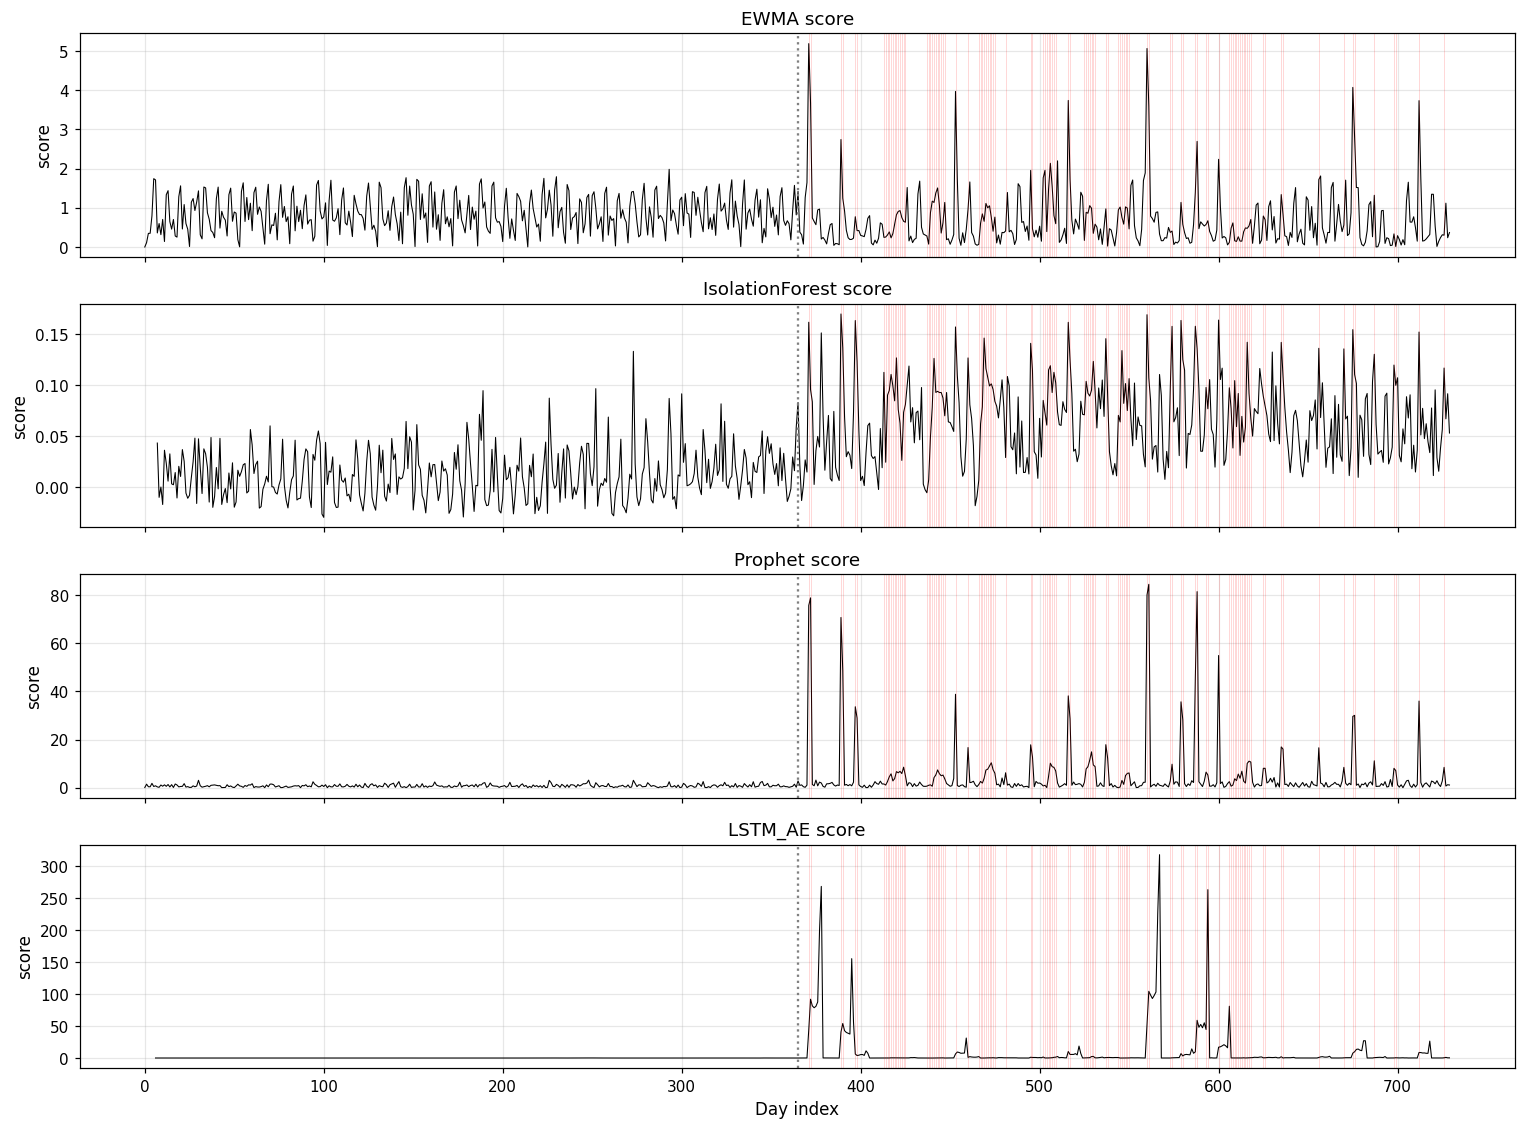

In [ ]:
def run_all_models(df, events_df, seed=RANDOM_SEED, year2_start=YEAR2_START,
                   include=("EWMA", "IsolationForest", "Prophet", "LSTM_AE"),
                   verbose=False):
    """
    4개 모델의 score를 일괄 계산하여 long-format DataFrame으로 합친다.

    Returns
    -------
    scores_long : DataFrame [model_name, date, day, score]
    aux         : dict, 모델별 보조 산출물 (예: prophet의 yhat_upper)
    """
    parts = []
    aux = {}

    if "EWMA" in include:
        if verbose:
            print("[EWMA] scoring ...")
        parts.append(score_with_ewma(df, events_df, seed=seed,
                                     year2_start=year2_start))

    if "IsolationForest" in include:
        if verbose:
            print("[IsolationForest] scoring ...")
        parts.append(score_with_iforest(df, events_df, seed=seed,
                                        year2_start=year2_start))

    if "Prophet" in include:
        if verbose:
            print("[Prophet] scoring ...")
        p_scores, p_aux = score_with_prophet(df, events_df, seed=seed,
                                             year2_start=year2_start,
                                             return_full=True)
        parts.append(p_scores)
        aux["Prophet"] = p_aux

    if "LSTM_AE" in include:
        if verbose:
            print("[LSTM_AE] scoring ...")
        parts.append(score_with_lstm_ae(df, events_df, seed=seed,
                                        year2_start=year2_start,
                                        n_epochs=60, verbose=False))

    scores_long = pd.concat(parts, axis=0, ignore_index=True)
    return scores_long, aux


# 단일 seed 실행
scores_long, model_aux = run_all_models(df, events_df, seed=RANDOM_SEED,
                                        verbose=True)
print("\nscores_long shape:", scores_long.shape)
print(scores_long.groupby("model_name")["score"]
      .describe()
      .round(3))


def plot_score_overview(df, scores_long, year2_start=YEAR2_START,
                        save_path=None):
    """
    모델별 score 시계열을 4분할 패널로 시각화.
    이상 구간을 회색 음영, 이상 점을 빨간 점으로 표시.
    """
    models = list(scores_long["model_name"].unique())
    fig, axes = plt.subplots(len(models), 1, figsize=(14, 2.6 * len(models)),
                             sharex=True)
    if len(models) == 1:
        axes = [axes]

    anomaly_days = df.loc[df["is_anomaly"], "day"].values

    for ax, name in zip(axes, models):
        sub = scores_long[scores_long["model_name"] == name]
        ax.plot(sub["day"], sub["score"], color="black", lw=0.7)
        for d in anomaly_days:
            ax.axvline(d, color="red", lw=0.4, alpha=0.25)
        ax.axvline(year2_start, color="gray", ls=":")
        ax.set_title(f"{name} score")
        ax.set_ylabel("score")
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("Day index")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    return fig


_ = plot_score_overview(
    df, scores_long,
    save_path=os.path.join(FIG_DIR, "03_score_overview.png"),
)
plt.show()

# Part 3. Threshold 적용, 평가 함수, single-seed 실행

평가 영역
- Threshold 보정 : Year 1 (day < year2_start)
- Metric 계산    : Year 2 (day >= year2_start)

평가 층
- point-wise : Precision, Recall, F1, AUPRC
- event-level: event recall, Detection Delay, False Alarm Rate
- cost-weighted: $-Recall, MCTD, Alert Cost Efficiency

규칙
- threshold 계산 시 score NaN은 dropna
- alert 계산 시 score NaN은 0으로 처리
- alert = score > threshold

## 7. Primary threshold 정책 + predictions_df 구성

각 모델별로 Year 1 score 분포의 99th percentile을 threshold로 사용한다.
이 셀이 끝나면 long-format `predictions_df`가 생긴다:

    model_name, date, day, score, threshold, alert,
    is_anomaly, anomaly_type, intensity_level, event_id, excess_cost

In [ ]:
def compute_thresholds(scores_long, year2_start=YEAR2_START, percentile=99.0):
    """
    각 모델별로 Year 1 (day < year2_start) score의 percentile을 threshold로 계산한다.

    Parameters
    ----------
    scores_long : DataFrame [model_name, date, day, score]
    year2_start : Year 2 시작 day index
    percentile  : 사용할 분위수 (0~100). Primary 정책은 99.

    Returns
    -------
    thresholds : dict {model_name: threshold(float)}
    """
    thresholds = {}
    for name, sub in scores_long.groupby("model_name"):
        # Year 1 구간 score만 사용, NaN은 분위수 계산에서 제외
        year1_scores = sub.loc[sub["day"] < year2_start, "score"].dropna().values
        if len(year1_scores) == 0:
            # 모든 score가 NaN이면 절대 alert가 안 발생하도록 +inf 설정
            thresholds[name] = float("inf")
        else:
            thresholds[name] = float(np.percentile(year1_scores, percentile))
    return thresholds


def build_predictions_df(df, scores_long, thresholds):
    """
    score / threshold / alert / label을 한 long-format으로 결합한다.

    NaN 처리
        - alert 비교 시 score는 NaN -> 0.0으로 채워 사용한다 (NaN 일은 알람 불가).
        - 단, score 컬럼 자체에는 NaN을 그대로 보존하여 추후 AUPRC 등에서 다시 처리한다.

    Parameters
    ----------
    df          : 표준 데이터 DataFrame (Part 1에서 생성)
    scores_long : long-format score DataFrame (Part 2에서 생성)
    thresholds  : dict {model_name: threshold}

    Returns
    -------
    predictions_df : DataFrame with columns
        [model_name, date, day, score, threshold, alert,
         is_anomaly, anomaly_type, intensity_level, event_id, excess_cost]
    """
    label_cols = ["day", "is_anomaly", "anomaly_type", "intensity_level",
                  "event_id", "excess_cost", "cost_impact"]
    labels = df[label_cols].copy()

    sl = scores_long.copy()
    sl["threshold"] = sl["model_name"].map(thresholds).astype(float)

    # NaN score는 0으로 가정하여 비교 (양의 threshold이므로 자동 탈락)
    score_for_cmp = sl["score"].fillna(0.0)
    sl["alert"] = (score_for_cmp > sl["threshold"]).astype(bool)

    pred = sl.merge(labels, on="day", how="left")

    # date 컬럼이 scores_long에 없을 가능성 대비
    if "date" not in pred.columns:
        pred = pred.merge(df[["day", "date"]], on="day", how="left")

    cols = ["model_name", "date", "day", "score", "threshold", "alert",
            "is_anomaly", "anomaly_type", "intensity_level", "event_id",
            "excess_cost", "cost_impact"]
    pred = pred[cols].sort_values(["model_name", "day"]).reset_index(drop=True)
    return pred


# sanity check
thresholds = compute_thresholds(scores_long, year2_start=YEAR2_START, percentile=99.0)
print("Primary thresholds (99th pct of Year 1 scores):")
for k, v in thresholds.items():
    print(f"  {k:18s} {v:.6f}")

predictions_df = build_predictions_df(df, scores_long, thresholds)
print("\npredictions_df shape:", predictions_df.shape)
print(predictions_df.head())
print("\nalerts in Year 2 by model:")
print(
    predictions_df[predictions_df["day"] >= YEAR2_START]
    .groupby("model_name")["alert"].sum()
)

Primary thresholds (99th pct of Year 1 scores):
  EWMA               1.746140
  IsolationForest    0.088920
  LSTM_AE            0.131385
  Prophet            2.744464

predictions_df shape: (2920, 12)
  model_name       date  day     score  threshold  alert  is_anomaly  \
0       EWMA 2024-01-01    0  0.000000    1.74614  False       False   
1       EWMA 2024-01-02    1  0.111314    1.74614  False       False   
2       EWMA 2024-01-03    2  0.346833    1.74614  False       False   
3       EWMA 2024-01-04    3  0.349989    1.74614  False       False   
4       EWMA 2024-01-05    4  0.793932    1.74614  False       False   

  anomaly_type intensity_level  event_id  excess_cost  cost_impact  
0         none            none         0    16.759439          0.0  
1         none            none         0   -59.828986          0.0  
2         none            none         0    43.194095          0.0  
3         none            none         0    54.163595          0.0  
4         none      

## 10. 평가 함수 구현

세 층의 metric을 작은 함수로 분리한 뒤 `evaluate_one_model`에서 합친다.

- `compute_pointwise_metrics` : Year 2 day 기준 Precision/Recall/F1/AUPRC
- `compute_far`               : Year 2 정상일 중 알람 비율
- `compute_event_results_one` : 이벤트 단위 detected/delay/MCTD
- `compute_cost_weighted`     : $-Recall, mean MCTD, Alert Cost Efficiency

In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score)


def compute_pointwise_metrics(pred_m, year2_start=YEAR2_START):
    """
    Year 2 구간에서 일 단위 (point-wise) 분류 metric을 계산한다.

    AUPRC는 raw score(NaN -> 0)에 대해 계산하여 ranking 품질을 반영한다.
    Precision/Recall/F1은 alert(boolean)에 대해 계산한다.

    Returns
    -------
    dict : precision, recall, f1, auprc
    """
    sub = pred_m[pred_m["day"] >= year2_start].copy()
    y_true  = sub["is_anomaly"].astype(int).values
    y_pred  = sub["alert"].astype(int).values
    y_score = sub["score"].fillna(0.0).values

    if y_pred.sum() == 0:
        precision = 0.0
    else:
        precision = float(precision_score(y_true, y_pred, zero_division=0))
    recall = float(recall_score(y_true, y_pred, zero_division=0))
    f1     = float(f1_score(y_true, y_pred, zero_division=0))

    # AUPRC는 양성이 하나도 없으면 정의 불가 -> 0 처리
    if y_true.sum() == 0:
        auprc = 0.0
    else:
        auprc = float(average_precision_score(y_true, y_score))

    return {"precision": precision, "recall": recall,
            "f1": f1, "auprc": auprc}


def compute_far(pred_m, year2_start=YEAR2_START):
    """
    False Alarm Rate
        = (Year 2 정상일 중 alert가 발생한 일수)
          / (Year 2 정상일 수)

    Returns
    -------
    float
    """
    sub = pred_m[pred_m["day"] >= year2_start]
    normal_mask = ~sub["is_anomaly"].astype(bool)
    n_normal = int(normal_mask.sum())
    if n_normal == 0:
        return 0.0
    n_false = int(sub.loc[normal_mask, "alert"].sum())
    return float(n_false) / float(n_normal)


def compute_event_results_one(pred_m, events_df, model_name):
    """
    한 모델에 대해 이벤트 단위 결과 DataFrame을 만든다.

    각 이벤트 [start_day, end_day]에 대해
        detected         : 기간 내 alert가 한 번이라도 있으면 True
        first_alert_day  : 기간 내 첫 alert day (없으면 NaN)
        detection_delay  : first_alert_day - start_day (미탐이면 NaN)
        mctd             : 탐지 직전까지의 excess_cost 누적합
                           - detected and first_alert_day == start_day -> 0
                           - detected and first_alert_day  > start_day -> sum [s, first_alert_day - 1]
                           - undetected                                -> sum [s, e]
        total_excess_cost: events_df의 값을 그대로 사용

    Parameters
    ----------
    pred_m     : 한 모델의 predictions slice (model_name 단일)
    events_df  : 이벤트 메타 DataFrame
    model_name : 결과 행에 부여할 모델 이름

    Returns
    -------
    DataFrame
    """
    # day 기반 fast lookup
    pdy = pred_m.sort_values("day").set_index("day")

    rows = []
    for _, ev in events_df.iterrows():
        s = int(ev["start_day"])
        e = int(ev["end_day"])
        seg = pdy.loc[s:e]                    # inclusive label slicing
        alerts = seg["alert"].values.astype(bool)

        if alerts.any():
            detected = True
            first_offset = int(np.argmax(alerts))
            first_alert_day = s + first_offset
            detection_delay = float(first_alert_day - s)
            if first_alert_day == s:
                mctd = 0.0
            else:
                mctd = float(pdy.loc[s:first_alert_day - 1, "cost_impact"].sum())
        else:
            detected = False
            first_alert_day = np.nan
            detection_delay = np.nan
            mctd = float(pdy.loc[s:e, "cost_impact"].sum())

        rows.append({
            "model_name": model_name,
            "event_id": int(ev["event_id"]),
            "anomaly_type": ev["anomaly_type"],
            "intensity_level": ev["intensity_level"],
            "start_day": s,
            "end_day": e,
            "detected": detected,
            "first_alert_day": first_alert_day,
            "detection_delay": detection_delay,
            "total_excess_cost": float(ev["total_excess_cost"]),
            "mctd": mctd,
        })

    return pd.DataFrame(rows)


def compute_cost_weighted(event_res_one, total_alerts_year2):
    """
    cost-weighted metric 계산.

    Parameters
    ----------
    event_res_one      : compute_event_results_one의 출력 (단일 모델)
    total_alerts_year2 : Year 2의 총 알람 수 (int)

    Returns
    -------
    dict : cost_weighted_recall, mean_mctd, alert_cost_efficiency
    """
    total_cost = float(event_res_one["total_excess_cost"].sum())
    detected_cost = float(
        event_res_one.loc[event_res_one["detected"], "total_excess_cost"].sum()
    )

    cost_recall = (detected_cost / total_cost) if total_cost > 0 else 0.0
    mean_mctd = (float(event_res_one["mctd"].mean())
                 if len(event_res_one) > 0 else 0.0)

    if total_alerts_year2 <= 0:
        ace = 0.0
    else:
        ace = detected_cost / float(total_alerts_year2)

    return {"cost_weighted_recall": cost_recall,
            "mean_mctd": mean_mctd,
            "alert_cost_efficiency": ace}

In [ ]:
def evaluate_one_model(pred_m, events_df, model_name, year2_start=YEAR2_START):
    """
    한 모델에 대해 모든 metric을 계산하여
        (metrics_dict, event_results_df) 튜플을 반환한다.
    """
    # event-level
    ev_res = compute_event_results_one(pred_m, events_df, model_name)
    if len(ev_res) > 0:
        event_recall = float(ev_res["detected"].mean())
        # detection_delay는 미탐 = NaN이므로 mean(skipna)이 자연 평균
        if ev_res["detected"].any():
            mean_dd = float(ev_res["detection_delay"].mean())
        else:
            mean_dd = float("nan")
    else:
        event_recall = 0.0
        mean_dd = float("nan")

    # point-wise
    pw = compute_pointwise_metrics(pred_m, year2_start=year2_start)

    # FAR
    far = compute_far(pred_m, year2_start=year2_start)

    # Year 2 전체 alert 수
    total_alerts = int(
        pred_m.loc[pred_m["day"] >= year2_start, "alert"].sum()
    )

    # cost-weighted
    cw = compute_cost_weighted(ev_res, total_alerts)

    threshold = float(pred_m["threshold"].iloc[0])

    metrics = {
        "model_name": model_name,
        "threshold": threshold,
        "total_alerts": total_alerts,
        "false_alarm_rate": far,
        "precision": pw["precision"],
        "recall": pw["recall"],
        "f1": pw["f1"],
        "auprc": pw["auprc"],
        "event_recall": event_recall,
        "mean_detection_delay": mean_dd,
        "cost_weighted_recall": cw["cost_weighted_recall"],
        "mean_mctd": cw["mean_mctd"],
        "alert_cost_efficiency": cw["alert_cost_efficiency"],
    }
    return metrics, ev_res


def run_evaluation(df, events_df, scores_long,
                   year2_start=YEAR2_START, percentile=99.0):
    """
    전체 모델에 대해 threshold 적용 + 평가를 실행하고,
    Part 3 명세의 세 DataFrame을 반환한다.

    Returns
    -------
    predictions_df    : long-format day-level
    model_metrics_df  : 모델 단위 요약
    event_results_df  : 모델 x 이벤트 단위 결과
    """
    thresholds = compute_thresholds(scores_long, year2_start=year2_start,
                                    percentile=percentile)
    predictions = build_predictions_df(df, scores_long, thresholds)

    metric_rows = []
    ev_parts = []
    for name in predictions["model_name"].unique():
        pred_m = (predictions[predictions["model_name"] == name]
                  .sort_values("day")
                  .reset_index(drop=True))
        m, ev_res = evaluate_one_model(pred_m, events_df, name,
                                       year2_start=year2_start)
        metric_rows.append(m)
        ev_parts.append(ev_res)

    metrics_cols = [
        "model_name", "threshold", "total_alerts", "false_alarm_rate",
        "precision", "recall", "f1", "auprc",
        "event_recall", "mean_detection_delay",
        "cost_weighted_recall", "mean_mctd", "alert_cost_efficiency",
    ]
    model_metrics = pd.DataFrame(metric_rows)[metrics_cols]
    event_results = pd.concat(ev_parts, axis=0, ignore_index=True)

    return predictions, model_metrics, event_results

## 11. single-seed 전체 평가 실행

Part 1의 df / events_df, Part 2의 scores_long을 입력으로
세 결과 DataFrame을 만들고 화면에 표시한다.

In [ ]:
# 단일 seed 전체 평가
predictions_df, model_metrics_df, event_results_df = run_evaluation(
    df, events_df, scores_long,
    year2_start=YEAR2_START, percentile=99.0,
)

print("=== model_metrics_df ===")
display_cols = [
    "model_name", "threshold", "total_alerts", "false_alarm_rate",
    "precision", "recall", "f1", "auprc",
    "event_recall", "mean_detection_delay",
    "cost_weighted_recall", "mean_mctd", "alert_cost_efficiency",
]
print(model_metrics_df[display_cols].round(4).to_string(index=False))

print("\n=== event_results_df: detection rate by (anomaly_type, intensity_level) ===")
ev_summary = (
    event_results_df
    .groupby(["model_name", "anomaly_type", "intensity_level"])["detected"]
    .mean()
    .unstack("intensity_level")
    .round(2)
)
print(ev_summary)

print("\n=== event_results_df: $-recall by anomaly_type ===")
def _dollar_recall_group(g):
    tot = g["total_excess_cost"].sum()
    det = g.loc[g["detected"], "total_excess_cost"].sum()
    return det / tot if tot > 0 else 0.0

cost_summary = (
    event_results_df
    .groupby(["model_name", "anomaly_type"])
    .apply(_dollar_recall_group)
    .unstack("anomaly_type")
    .round(3)
)
print(cost_summary)

print("\n=== predictions_df shape:", predictions_df.shape)
print("=== event_results_df shape:", event_results_df.shape)

=== model_metrics_df ===
     model_name  threshold  total_alerts  false_alarm_rate  precision  recall     f1  auprc  event_recall  mean_detection_delay  cost_weighted_recall  mean_mctd  alert_cost_efficiency
           EWMA     1.7461            19            0.0117     0.8421  0.1481 0.2520 0.5334        0.3548                0.0909                0.5777  1199.3509              2494.8647
IsolationForest     0.0889           107            0.1401     0.6636  0.6574 0.6605 0.7314        0.9355                0.4483                0.9856    74.7248               755.8418
        LSTM_AE     0.1314           241            0.6498     0.3071  0.6852 0.4241 0.2856        1.0000                0.3226                1.0000    37.5271               340.4978
        Prophet     2.7445            99            0.0506     0.8687  0.7963 0.8309 0.8939        1.0000                0.6129                1.0000    50.5598               828.8887

=== event_results_df: detection rate by (anomaly_type,

# Part 4. Multi-seed 실행, 결과 요약, 시각화, csv 저장

이 파트는 Part 1~3 함수를 그대로 재사용하는 얇은 wrapper다.

핵심 루프
    for seed in SEEDS:
        df, events_df = build_dataset(seed)
        scores_long  = run_all_models(df, events_df, seed)
        for (budget, quantile) in BUDGETS:
            run_evaluation(df, events_df, scores_long, percentile=quantile)

Budget → threshold quantile 매핑
    0.5%  -> 99.5th percentile
    1.0%  -> 99.0th percentile
    2.0%  -> 98.0th percentile

## 12-0. 경로/상수 설정 및 헬퍼

In [ ]:
# 결과 저장 경로 (요청 명세)
RESULTS_DIR = "/content/finops_benchmark/results"
FIGS_DIR_NEW = "/content/finops_benchmark/figures"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGS_DIR_NEW, exist_ok=True)

# 실험 설정
SEEDS = list(range(10))                     # 10 seeds
BUDGETS = [
    (0.005, 99.5),                          # 0.5% budget
    (0.010, 99.0),                          # 1.0% budget (Primary)
    (0.020, 98.0),                          # 2.0% budget
]

# summary 시 mean/std를 적용할 metric 컬럼들 (model_metrics_df의 수치 컬럼)
METRIC_COLS = [
    "threshold", "total_alerts", "false_alarm_rate",
    "precision", "recall", "f1", "auprc",
    "event_recall", "mean_detection_delay",
    "cost_weighted_recall", "mean_mctd", "alert_cost_efficiency",
]

# event_results_df에서 보존할 컬럼 (요청 명세)
EVENT_KEEP_COLS = [
    "seed", "budget", "model_name", "event_id",
    "anomaly_type", "intensity_level",
    "detected", "detection_delay", "total_excess_cost", "mctd",
]

print("RESULTS_DIR:", RESULTS_DIR)
print("FIGS_DIR_NEW:", FIGS_DIR_NEW)
print("SEEDS:", SEEDS)
print("BUDGETS:", BUDGETS)

RESULTS_DIR: /content/finops_benchmark/results
FIGS_DIR_NEW: /content/finops_benchmark/figures
SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
BUDGETS: [(0.005, 99.5), (0.01, 99.0), (0.02, 98.0)]


## 12-1. 단일 seed 실행 wrapper

한 seed에 대해
- 데이터 생성
- 4개 모델 score 계산
- 3개 budget으로 threshold 적용 + 평가

를 수행하고, model_metrics와 event_results를 long-format 조각으로 반환한다.

In [ ]:
def run_one_seed(seed, year2_start=YEAR2_START, budgets=BUDGETS, verbose=False):
    """
    한 seed에 대해 데이터 생성 -> 모델 score -> 다중 budget 평가까지 수행한다.

    Parameters
    ----------
    seed         : 실험 시드 (build_dataset, run_all_models, threshold 모두에 동일하게 사용)
    year2_start  : Year 2 시작 day index
    budgets      : [(budget_float, percentile_float), ...]
    verbose      : 진행 상황 출력 여부

    Returns
    -------
    metrics_df : 한 seed에서 모든 (budget x model) 조합의 model_metrics 행
                 추가 컬럼: seed, budget, threshold_quantile
    events_df  : 한 seed에서 모든 (budget x model x event) 조합의 event_results 행
                 추가 컬럼: seed, budget
    """
    if verbose:
        print(f"[seed={seed}] generating data and scoring all models ...")

    # 1) 데이터 생성 (Part 1 함수 재사용)
    df_s, events_table_s = build_dataset(seed=seed,
                                         n_days=N_DAYS,
                                         year2_start=year2_start,
                                         start_date=START_DATE)

    # 2) 4개 모델 score 일괄 계산 (Part 2 함수 재사용)
    scores_s, _aux = run_all_models(df_s, events_table_s,
                                    seed=seed, year2_start=year2_start,
                                    verbose=False)

    # 3) budget별 threshold 적용 + 평가 (Part 3 함수 재사용)
    metric_parts = []
    event_parts = []
    for budget, q in budgets:
        _pred_s, met_s, ev_s = run_evaluation(
            df_s, events_table_s, scores_s,
            year2_start=year2_start, percentile=q,
        )

        # 메타 정보 부착 (long-format 식별 키)
        met_s = met_s.copy()
        met_s.insert(0, "seed", seed)
        met_s.insert(1, "budget", budget)
        met_s.insert(2, "threshold_quantile", q)

        ev_s = ev_s.copy()
        ev_s.insert(0, "seed", seed)
        ev_s.insert(1, "budget", budget)

        metric_parts.append(met_s)
        event_parts.append(ev_s)

    metrics_df = pd.concat(metric_parts, axis=0, ignore_index=True)
    events_df = pd.concat(event_parts, axis=0, ignore_index=True)
    return metrics_df, events_df


# sanity check (single seed, 빠르게 한 번만)
_m, _e = run_one_seed(seed=0, verbose=True)
print("single-seed metrics rows:", len(_m), " event rows:", len(_e))
print(_m[["seed", "budget", "model_name", "f1",
          "cost_weighted_recall", "alert_cost_efficiency"]].round(3))

[seed=0] generating data and scoring all models ...
single-seed metrics rows: 12  event rows: 336
    seed  budget       model_name     f1  cost_weighted_recall  \
0      0   0.005             EWMA  0.246                 0.556   
1      0   0.005  IsolationForest  0.595                 0.951   
2      0   0.005          LSTM_AE  0.362                 0.986   
3      0   0.005          Prophet  0.856                 1.000   
4      0   0.010             EWMA  0.258                 0.556   
5      0   0.010  IsolationForest  0.607                 0.951   
6      0   0.010          LSTM_AE  0.405                 0.993   
7      0   0.010          Prophet  0.837                 1.000   
8      0   0.020             EWMA  0.272                 0.610   
9      0   0.020  IsolationForest  0.657                 0.964   
10     0   0.020          LSTM_AE  0.429                 0.993   
11     0   0.020          Prophet  0.822                 1.000   

    alert_cost_efficiency  
0              

## 12-2. 10 seeds 전체 실행

Prophet 첫 컴파일 + LSTM AE 학습 때문에 시간이 걸린다.
seed 1개당 대략 1~2분 (CPU 기준), 총 10~20분 예상.

In [ ]:
from tqdm.auto import tqdm

all_metrics_parts = []
all_events_parts = []

for s in tqdm(SEEDS, desc="seeds"):
    m_s, e_s = run_one_seed(seed=s, verbose=False)
    all_metrics_parts.append(m_s)
    all_events_parts.append(e_s)

# 통합 long-format DataFrame
all_model_metrics_df = pd.concat(all_metrics_parts, axis=0, ignore_index=True)
all_event_results_df_full = pd.concat(all_events_parts, axis=0, ignore_index=True)

# 명세에 맞춰 event_results는 지정 컬럼만 남긴다
all_event_results_df = all_event_results_df_full[EVENT_KEEP_COLS].copy()

print("all_model_metrics_df shape:", all_model_metrics_df.shape)
print("all_event_results_df shape:", all_event_results_df.shape)
print("\nsample:")
print(all_model_metrics_df.head())

seeds:   0%|          | 0/10 [00:00<?, ?it/s]

all_model_metrics_df shape: (120, 16)
all_event_results_df shape: (3636, 10)

sample:
   seed  budget  threshold_quantile       model_name  threshold  total_alerts  \
0     0   0.005                99.5             EWMA   1.804798            19   
1     0   0.005                99.5  IsolationForest   0.110945            55   
2     0   0.005                99.5          LSTM_AE   0.207303           195   
3     0   0.005                99.5          Prophet   3.235438            84   
4     0   0.010                99.0             EWMA   1.751183            21   

   false_alarm_rate  precision    recall        f1     auprc  event_recall  \
0          0.015267   0.789474  0.145631  0.245902  0.532573      0.357143   
1          0.030534   0.854545  0.456311  0.594937  0.724006      0.821429   
2          0.538168   0.276923  0.524272  0.362416  0.271218      0.928571   
3          0.015267   0.952381  0.776699  0.855615  0.896710      1.000000   
4          0.019084   0.761905  0.155

## 13. 결과 요약표 생성

(budget x model_name) 그룹별 mean / std 산출.
mean_detection_delay는 미탐 이벤트가 NaN이라 mean(skipna)이 자동 적용된다.

In [ ]:
def build_summary_metrics(all_model_metrics_df, metric_cols=METRIC_COLS):
    """
    seed 차원을 평균/표준편차로 축약하여 (budget, model_name) 단위 요약표를 만든다.

    반환 컬럼
        budget, model_name,
        <metric>_mean, <metric>_std (각 metric_cols 항목)
    """
    grp = (all_model_metrics_df
           .groupby(["budget", "model_name"])[metric_cols]
           .agg(["mean", "std"]))

    # MultiIndex 컬럼을 평탄화: ('f1','mean') -> 'f1_mean'
    grp.columns = [f"{m}_{stat}" for m, stat in grp.columns]
    grp = grp.reset_index().sort_values(["budget", "model_name"])
    return grp


summary_metrics_df = build_summary_metrics(all_model_metrics_df, METRIC_COLS)

# 화면 표시는 핵심 컬럼만
display_cols = [
    "budget", "model_name",
    "f1_mean", "f1_std",
    "cost_weighted_recall_mean", "cost_weighted_recall_std",
    "alert_cost_efficiency_mean", "alert_cost_efficiency_std",
    "mean_mctd_mean", "mean_mctd_std",
    "false_alarm_rate_mean", "false_alarm_rate_std",
]
print("=== summary_metrics_df (key columns) ===")
print(summary_metrics_df[display_cols].round(4).to_string(index=False))

=== summary_metrics_df (key columns) ===
 budget      model_name  f1_mean  f1_std  cost_weighted_recall_mean  cost_weighted_recall_std  alert_cost_efficiency_mean  alert_cost_efficiency_std  mean_mctd_mean  mean_mctd_std  false_alarm_rate_mean  false_alarm_rate_std
  0.005            EWMA   0.2833  0.0441                     0.6135                    0.0602                   1840.7152                   242.2651        971.9915       162.6074                 0.0203                0.0079
  0.005 IsolationForest   0.5853  0.0891                     0.9734                    0.0216                   1055.9820                   222.1884        184.7297       109.0222                 0.0630                0.0341
  0.005         LSTM_AE   0.3879  0.0453                     0.9861                    0.0201                    288.9167                    41.0291        134.0385        64.4206                 0.6615                0.0802
  0.005         Prophet   0.8225  0.0341                   

## 13-1. F1 rank vs cost-weighted rank 비교표

budget=1% 기준으로
- F1 평균 기준 순위
- cost_weighted_recall 평균 기준 순위
- alert_cost_efficiency 평균 기준 순위

세 지표의 순위가 어긋나는 정도가 곧 "비용 인지 평가의 부가가치".

In [ ]:
def build_rank_table(all_model_metrics_df, budget=0.01):
    """
    지정 budget에서 모델별 F1, cost_weighted_recall, alert_cost_efficiency
    평균값과 그 순위를 한 표에 정리한다 (낮은 rank = 더 좋음).
    """
    sub = (all_model_metrics_df[all_model_metrics_df["budget"] == budget]
           .groupby("model_name")[["f1",
                                   "cost_weighted_recall",
                                   "alert_cost_efficiency",
                                   "mean_mctd"]]
           .mean()
           .round(4))

    sub["f1_rank"] = sub["f1"].rank(ascending=False, method="min").astype(int)
    sub["dollar_recall_rank"] = (
        sub["cost_weighted_recall"].rank(ascending=False, method="min").astype(int)
    )
    sub["ace_rank"] = (
        sub["alert_cost_efficiency"].rank(ascending=False, method="min").astype(int)
    )
    # MCTD는 낮을수록 좋음
    sub["mctd_rank"] = sub["mean_mctd"].rank(ascending=True, method="min").astype(int)

    return sub.reset_index().sort_values("f1_rank")


rank_table = build_rank_table(all_model_metrics_df, budget=0.01)
print("=== Rank comparison at budget=1% ===")
print(rank_table.to_string(index=False))

=== Rank comparison at budget=1% ===
     model_name     f1  cost_weighted_recall  alert_cost_efficiency  mean_mctd  f1_rank  dollar_recall_rank  ace_rank  mctd_rank
        Prophet 0.8156                0.9996               684.3307    33.0558        1                   1         3          1
IsolationForest 0.6037                0.9819               804.3571   128.3478        2                   3         2          3
        LSTM_AE 0.3962                0.9873               281.3526   125.0031        3                   2         4          2
           EWMA 0.2887                0.6199              1753.1376   961.3830        4                   4         1          4


## 14. 시각화

1) budget=1% F1 bar (mean ± std)
2) budget=1% cost_weighted_recall bar
3) budget=1% alert_cost_efficiency bar
4) budget별 F1 line chart
5) budget별 alert_cost_efficiency line chart

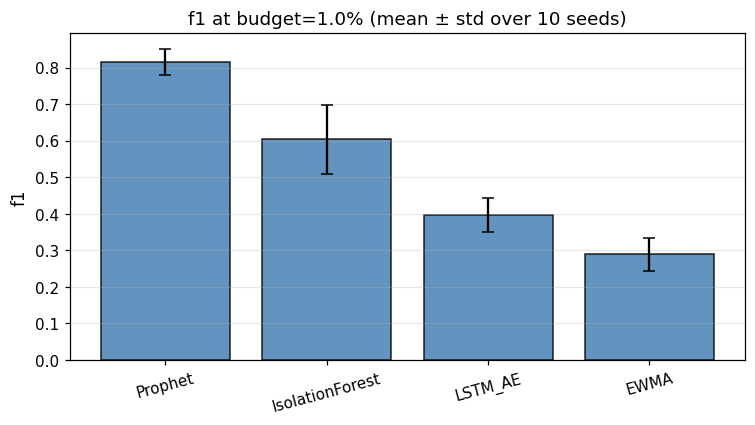

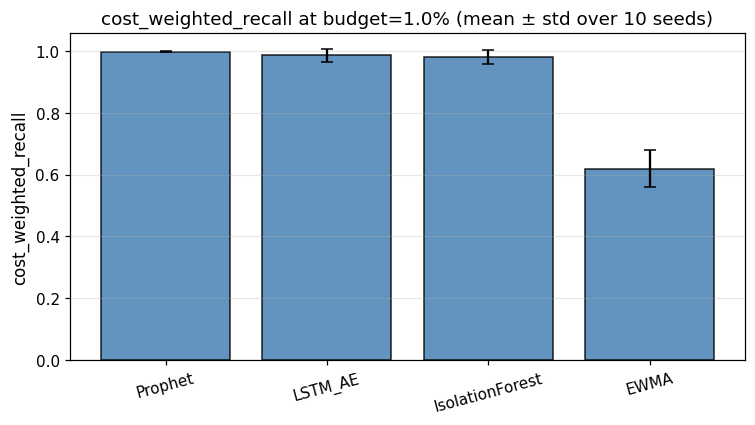

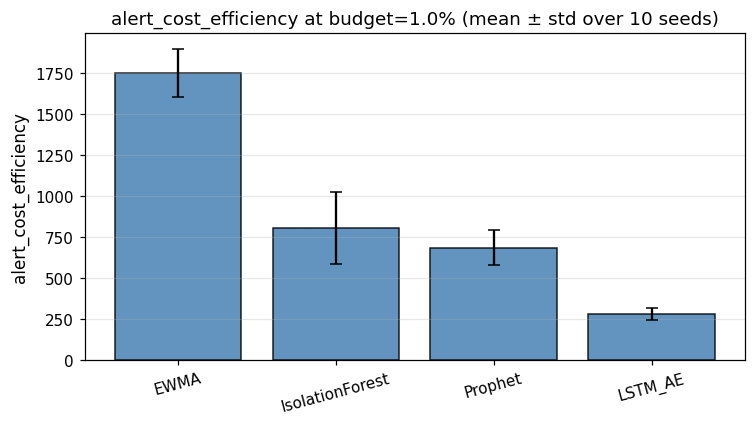

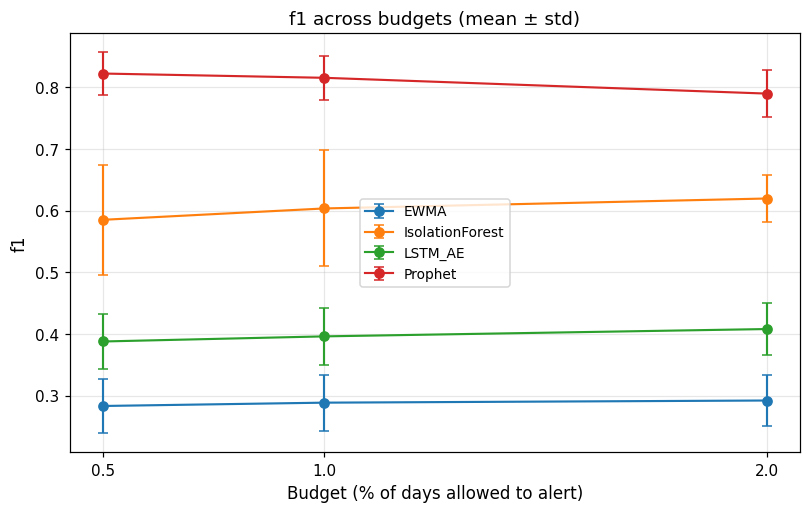

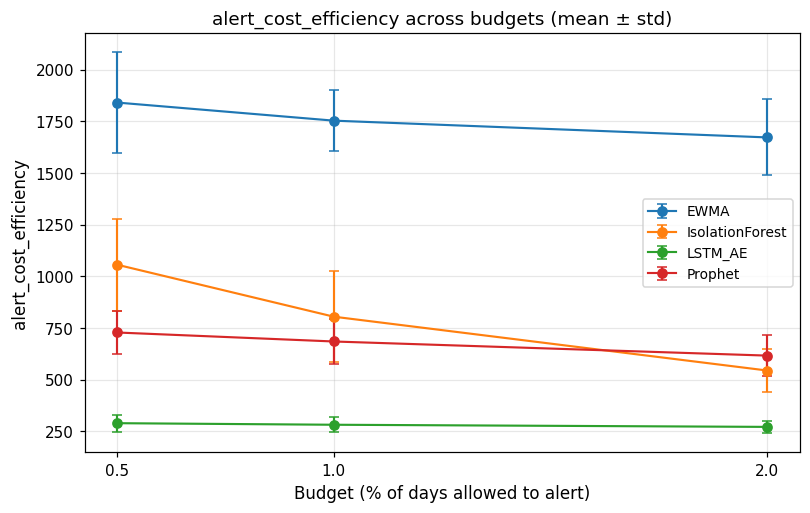

In [ ]:
def _bar_with_err(ax, names, means, stds, ylabel, title):
    """
    공통 막대 그래프 헬퍼: yerr 포함, mean 정렬은 호출자 책임.
    """
    ax.bar(names, means, yerr=stds, capsize=4,
           color="steelblue", edgecolor="black", alpha=0.85)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    for tick in ax.get_xticklabels():
        tick.set_rotation(15)


def plot_budget1_bar(summary_metrics_df, metric, save_path,
                     budget=0.01, ascending_better=False):
    """
    한 budget에서 모델별 metric 평균을 막대로, 표준편차를 errorbar로 그린다.

    Parameters
    ----------
    metric            : 'f1', 'cost_weighted_recall', 'alert_cost_efficiency' 등
    ascending_better  : True면 작을수록 좋은 metric (정렬 방향만 다름)
    """
    sub = summary_metrics_df[summary_metrics_df["budget"] == budget].copy()
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"
    sub = sub.sort_values(mean_col, ascending=ascending_better)

    fig, ax = plt.subplots(figsize=(7, 4))
    _bar_with_err(
        ax,
        sub["model_name"].values,
        sub[mean_col].values,
        sub[std_col].values,
        ylabel=metric,
        title=f"{metric} at budget={budget*100:.1f}% (mean ± std over {len(SEEDS)} seeds)",
    )
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    return fig


def plot_metric_by_budget(summary_metrics_df, metric, save_path):
    """
    x축 budget, y축 metric mean, 모델별 라인. errorbar = std.
    """
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"

    for name, sub in summary_metrics_df.groupby("model_name"):
        sub = sub.sort_values("budget")
        ax.errorbar(sub["budget"].values * 100,
                    sub[mean_col].values,
                    yerr=sub[std_col].values,
                    marker="o", capsize=3, lw=1.4, label=name)

    ax.set_xlabel("Budget (% of days allowed to alert)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} across budgets (mean ± std)")
    ax.set_xticks([b * 100 for b, _ in BUDGETS])
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    return fig


# 1) ~ 3) budget=1% 기준 bar charts
_ = plot_budget1_bar(summary_metrics_df, "f1",
                     os.path.join(FIGS_DIR_NEW, "10_f1_bar_budget1pct.png"))
plt.show()

_ = plot_budget1_bar(summary_metrics_df, "cost_weighted_recall",
                     os.path.join(FIGS_DIR_NEW, "11_dollar_recall_bar_budget1pct.png"))
plt.show()

_ = plot_budget1_bar(summary_metrics_df, "alert_cost_efficiency",
                     os.path.join(FIGS_DIR_NEW, "12_ace_bar_budget1pct.png"))
plt.show()

# 4) ~ 5) budget별 line charts
_ = plot_metric_by_budget(summary_metrics_df, "f1",
                          os.path.join(FIGS_DIR_NEW, "13_f1_by_budget.png"))
plt.show()

_ = plot_metric_by_budget(summary_metrics_df, "alert_cost_efficiency",
                          os.path.join(FIGS_DIR_NEW, "14_ace_by_budget.png"))
plt.show()

## 14-1. F1 rank vs ACE rank 비교 시각화 (보너스, 단순 표 + 선)

bump chart 대신 두 rank를 양 끝에 두고 선으로 잇는 단순 시각화.
순위 역전이 한눈에 보이도록 의도.

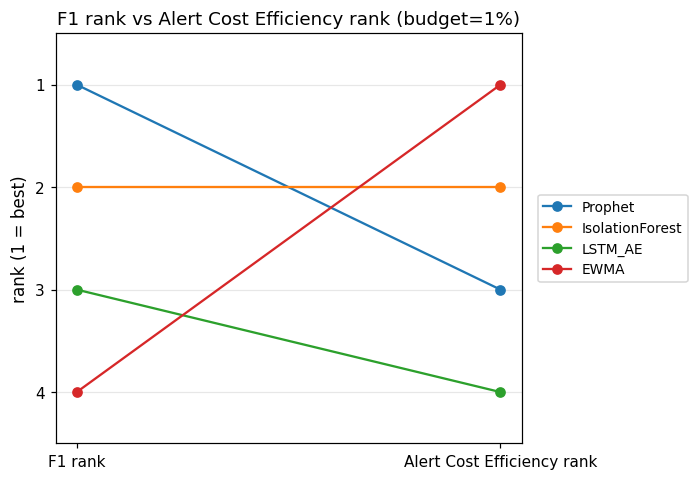

In [ ]:
def plot_rank_comparison(rank_table, save_path):
    """
    F1 rank와 alert_cost_efficiency rank를 좌우로 배치하고 모델별로 선으로 잇는다.
    rank가 1=best (위쪽), 4=worst (아래쪽)이 되도록 y축을 반전한다.
    """
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    n = len(rank_table)

    for _, row in rank_table.iterrows():
        ax.plot([0, 1], [row["f1_rank"], row["ace_rank"]],
                marker="o", lw=1.5, label=row["model_name"])

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["F1 rank", "Alert Cost Efficiency rank"])
    ax.set_yticks(range(1, n + 1))
    ax.set_ylim(n + 0.5, 0.5)         # 1이 위쪽
    ax.set_ylabel("rank (1 = best)")
    ax.set_title("F1 rank vs Alert Cost Efficiency rank (budget=1%)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    return fig


_ = plot_rank_comparison(
    rank_table,
    os.path.join(FIGS_DIR_NEW, "15_rank_compare_f1_vs_ace.png"),
)
plt.show()

## 15. csv 저장

In [ ]:
metrics_csv = os.path.join(RESULTS_DIR, "all_model_metrics.csv")
summary_csv = os.path.join(RESULTS_DIR, "summary_metrics.csv")
events_csv = os.path.join(RESULTS_DIR, "all_event_results.csv")

all_model_metrics_df.to_csv(metrics_csv, index=False)
summary_metrics_df.to_csv(summary_csv, index=False)
all_event_results_df.to_csv(events_csv, index=False)

print("saved:")
for p in [metrics_csv, summary_csv, events_csv]:
    print(" ", p, "(", os.path.getsize(p), "bytes )")

print("\nfigures dir:", FIGS_DIR_NEW)
for f in sorted(os.listdir(FIGS_DIR_NEW)):
    print(" ", f)

saved:
  /content/finops_benchmark/results/all_model_metrics.csv ( 25769 bytes )
  /content/finops_benchmark/results/summary_metrics.csv ( 6033 bytes )
  /content/finops_benchmark/results/all_event_results.csv ( 215025 bytes )

figures dir: /content/finops_benchmark/figures
  10_f1_bar_budget1pct.png
  11_dollar_recall_bar_budget1pct.png
  12_ace_bar_budget1pct.png
  13_f1_by_budget.png
  14_ace_by_budget.png
  15_rank_compare_f1_vs_ace.png
  paper_ace_bar_budget1pct.png
  paper_dollar_recall_bar_budget1pct.png
  paper_f1_bar_budget1pct.png
  paper_f1_by_budget.png
  paper_far_by_budget.png
  paper_mctd_by_budget.png


# Part 5. 논문/보고서용 결과 정리

본 섹션은 multi-seed 결과를 받아 paper-ready 형식으로 정리한다.
- 핵심 결과표: budget=1% 기준 mean ± std
- 순위 비교표: F1 / $-Recall / ACE / MCTD
- 논문 그림 6종: bar chart 3개 + line chart 3개

기존 Part 4 figure(10_~15_)는 그대로 두고,
이 섹션에서 만드는 figure는 `paper_` prefix를 붙여 별도 파일로 저장한다.

## 1) 핵심 결과표 (budget=1%)

각 metric을 `mean ± std` 문자열로 포맷한다.
- F1, $-Recall, ACE, FAR : 소수점 3자리
- MCTD                   : 절대 비용값이라 천 단위 구분 + 소수점 1자리
- 행 순서 : F1 mean 내림차순

In [ ]:
def _format_mean_std(mean, std, kind="ratio"):
    """
    metric 한 쌍을 'mean ± std' 문자열로 포맷한다.

    Parameters
    ----------
    mean : float
    std  : float (NaN이면 0으로 표시)
    kind : "ratio" | "money"
        ratio  : 0~1 또는 작은 실수 (소수점 3자리)
        money  : 비용 단위 (천 단위 콤마, 소수점 1자리)
    """
    if std is None or (isinstance(std, float) and np.isnan(std)):
        std = 0.0
    if kind == "money":
        return f"{mean:,.1f} \u00b1 {std:,.1f}"
    return f"{mean:.3f} \u00b1 {std:.3f}"


def build_core_results_table(summary_df, budget=0.01):
    """
    budget=1% 기준 paper-ready 핵심 결과표를 만든다.

    포함 metric
        f1, cost_weighted_recall, alert_cost_efficiency,
        mean_mctd, false_alarm_rate

    행 순서는 f1 mean 내림차순.
    """
    sub = summary_df[summary_df["budget"] == budget].copy()

    rows = []
    # f1 내림차순으로 순회
    sub_sorted = sub.sort_values("f1_mean", ascending=False)
    for _, r in sub_sorted.iterrows():
        rows.append({
            "model_name": r["model_name"],
            "f1": _format_mean_std(r["f1_mean"], r["f1_std"], "ratio"),
            "cost_weighted_recall": _format_mean_std(
                r["cost_weighted_recall_mean"],
                r["cost_weighted_recall_std"], "ratio"),
            "alert_cost_efficiency": _format_mean_std(
                r["alert_cost_efficiency_mean"],
                r["alert_cost_efficiency_std"], "money"),
            "mean_mctd": _format_mean_std(
                r["mean_mctd_mean"],
                r["mean_mctd_std"], "money"),
            "false_alarm_rate": _format_mean_std(
                r["false_alarm_rate_mean"],
                r["false_alarm_rate_std"], "ratio"),
        })

    return pd.DataFrame(rows)


core_results_df = build_core_results_table(summary_metrics_df, budget=0.01)

print("=== Core results table at budget=1% (mean \u00b1 std over seeds) ===")
print(core_results_df.to_string(index=False))

core_results_csv = os.path.join(RESULTS_DIR, "paper_core_results_budget1pct.csv")
core_results_df.to_csv(core_results_csv, index=False)
print(f"\nsaved: {core_results_csv}")

=== Core results table at budget=1% (mean ± std over seeds) ===
     model_name            f1 cost_weighted_recall alert_cost_efficiency     mean_mctd false_alarm_rate
        Prophet 0.816 ± 0.036        1.000 ± 0.001         684.3 ± 107.3   33.1 ± 12.8    0.073 ± 0.032
IsolationForest 0.604 ± 0.094        0.982 ± 0.023         804.4 ± 220.1 128.3 ± 123.5    0.119 ± 0.051
        LSTM_AE 0.396 ± 0.047        0.987 ± 0.020          281.4 ± 36.0  125.0 ± 63.9    0.675 ± 0.078
           EWMA 0.289 ± 0.045        0.620 ± 0.061       1,753.1 ± 146.3 961.4 ± 169.4    0.023 ± 0.008

saved: /content/finops_benchmark/results/paper_core_results_budget1pct.csv


## 2) Rank comparison table (budget=1%)

방향
- higher-is-better : f1, cost_weighted_recall, alert_cost_efficiency
- lower-is-better  : mean_mctd

`method="min"`을 사용해 동률은 같은 rank로 처리.

In [ ]:
def build_rank_comparison(all_metrics_df, budget=0.01):
    """
    각 모델의 metric 평균값과 그 순위를 한 표에 정리한다.

    rank 규칙
        - f1, cost_weighted_recall, alert_cost_efficiency : 큰 값이 1위
        - mean_mctd                                       : 작은 값이 1위
        - 동률 처리 method="min"

    Returns
    -------
    DataFrame
        model_name, f1, f1_rank,
        cost_weighted_recall, dollar_recall_rank,
        alert_cost_efficiency, ace_rank,
        mean_mctd, mctd_rank
    """
    sub = (all_metrics_df[all_metrics_df["budget"] == budget]
           .groupby("model_name")[["f1",
                                   "cost_weighted_recall",
                                   "alert_cost_efficiency",
                                   "mean_mctd"]]
           .mean())

    sub["f1_rank"] = sub["f1"].rank(ascending=False, method="min").astype(int)
    sub["dollar_recall_rank"] = (
        sub["cost_weighted_recall"]
        .rank(ascending=False, method="min").astype(int)
    )
    sub["ace_rank"] = (
        sub["alert_cost_efficiency"]
        .rank(ascending=False, method="min").astype(int)
    )
    sub["mctd_rank"] = (
        sub["mean_mctd"].rank(ascending=True, method="min").astype(int)
    )

    out = sub.reset_index()
    out = out[[
        "model_name",
        "f1", "f1_rank",
        "cost_weighted_recall", "dollar_recall_rank",
        "alert_cost_efficiency", "ace_rank",
        "mean_mctd", "mctd_rank",
    ]].sort_values("f1_rank").reset_index(drop=True)

    # 수치 컬럼은 보기 좋게 반올림
    out["f1"] = out["f1"].round(4)
    out["cost_weighted_recall"] = out["cost_weighted_recall"].round(4)
    out["alert_cost_efficiency"] = out["alert_cost_efficiency"].round(2)
    out["mean_mctd"] = out["mean_mctd"].round(2)
    return out


rank_comparison_df = build_rank_comparison(all_model_metrics_df, budget=0.01)

print("=== Rank comparison at budget=1% ===")
print(rank_comparison_df.to_string(index=False))

rank_csv = os.path.join(RESULTS_DIR, "paper_rank_comparison_budget1pct.csv")
rank_comparison_df.to_csv(rank_csv, index=False)
print(f"\nsaved: {rank_csv}")

=== Rank comparison at budget=1% ===
     model_name     f1  f1_rank  cost_weighted_recall  dollar_recall_rank  alert_cost_efficiency  ace_rank  mean_mctd  mctd_rank
        Prophet 0.8156        1                0.9996                   1                 684.33         3      33.06          1
IsolationForest 0.6037        2                0.9819                   3                 804.36         2     128.35          3
        LSTM_AE 0.3962        3                0.9873                   2                 281.35         4     125.00          2
           EWMA 0.2887        4                0.6199                   4                1753.14         1     961.38          4

saved: /content/finops_benchmark/results/paper_rank_comparison_budget1pct.csv


## 3) 논문 그림 6종

공통 디자인
- matplotlib만 사용 (seaborn 미사용)
- DPI 200, errorbar = std
- bar chart 모델 순서는 F1 내림차순으로 통일하여 시각적 비교 일관성 확보
- line chart는 모델별 색상을 고정하여 그림 간 동일 모델 식별 용이

In [ ]:
# 논문용 matplotlib 공통 설정
PAPER_DPI = 200
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 110,
})

# 모델별 색상 (line chart 일관성용)
PAPER_COLOR_MAP = {
    "EWMA":            "#1f77b4",
    "IsolationForest": "#d62728",
    "LSTM_AE":         "#2ca02c",
    "Prophet":         "#9467bd",
}


def get_canonical_model_order(summary_df, budget=0.01):
    """
    F1 mean 내림차순으로 모델 이름 리스트를 반환한다.
    bar chart 3종은 모두 이 순서를 따른다.
    """
    sub = (summary_df[summary_df["budget"] == budget]
           .sort_values("f1_mean", ascending=False))
    return sub["model_name"].tolist()


def _adaptive_label(v):
    """
    bar chart 위에 표시할 값 레이블을 스케일에 맞게 포맷한다.
    """
    av = abs(v)
    if av < 10:
        return f"{v:.3f}"
    if av < 1000:
        return f"{v:.1f}"
    return f"{v:,.0f}"


CANONICAL_ORDER = get_canonical_model_order(summary_metrics_df, budget=0.01)
print("Canonical model order (by F1 desc at budget=1%):", CANONICAL_ORDER)

Canonical model order (by F1 desc at budget=1%): ['Prophet', 'IsolationForest', 'LSTM_AE', 'EWMA']


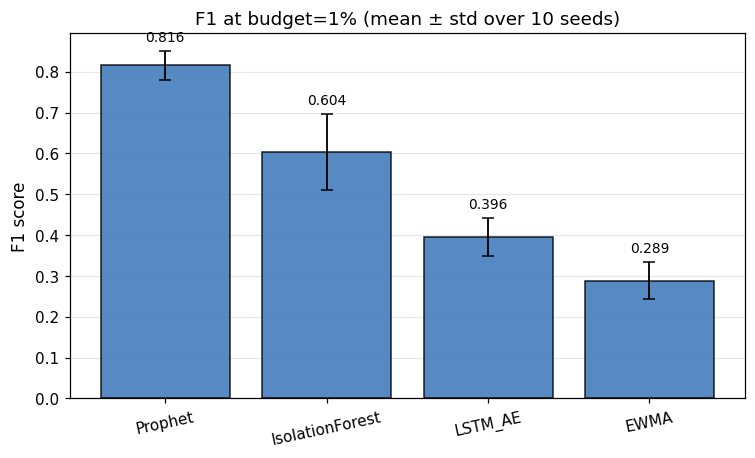

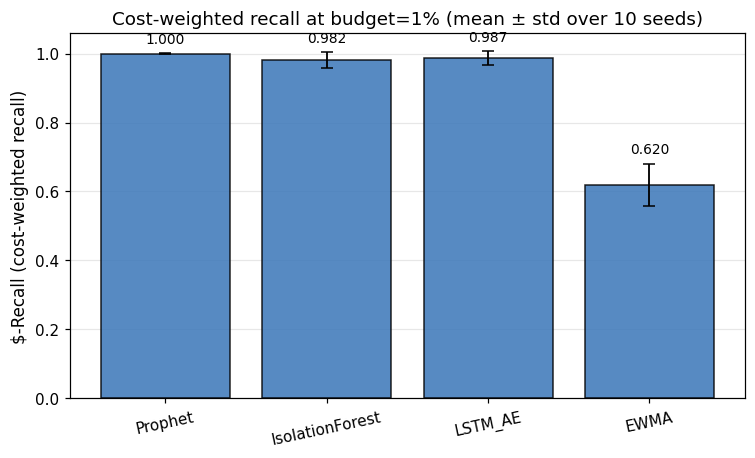

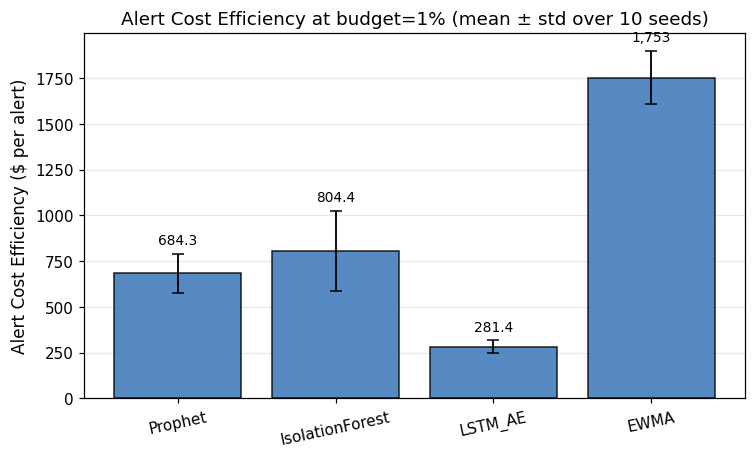

In [ ]:
def plot_paper_bar(summary_df, metric, save_path,
                   budget=0.01, ylabel=None, title=None,
                   model_order=None,
                   bar_color="#3a76b8"):
    """
    budget=1% 기준 paper-ready 막대 그래프.

    - mean을 막대 높이, std를 errorbar로 표시
    - 막대 위에 mean 값 텍스트 라벨 표시 (스케일에 따라 자동 포맷)
    - 모델 순서는 model_order로 고정 (None이면 입력 순서)

    Parameters
    ----------
    summary_df  : summary_metrics_df
    metric      : 'f1' | 'cost_weighted_recall' | 'alert_cost_efficiency' 등
    save_path   : png 저장 경로
    """
    sub = summary_df[summary_df["budget"] == budget].copy()
    if model_order is not None:
        sub = (sub.set_index("model_name")
                  .loc[model_order]
                  .reset_index())

    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"
    means = sub[mean_col].values.astype(float)
    stds = sub[std_col].fillna(0.0).values.astype(float)

    fig, ax = plt.subplots(figsize=(7.0, 4.3))
    bars = ax.bar(sub["model_name"], means, yerr=stds, capsize=4,
                  color=bar_color, edgecolor="black", alpha=0.85,
                  error_kw={"elinewidth": 1.2, "ecolor": "black"})

    # 값 라벨 (errorbar 위쪽으로 살짝 띄움)
    pad = 0.02 * (max(means) if max(means) > 0 else 1.0)
    for bar, mu, sd in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + sd + pad,
                _adaptive_label(mu),
                ha="center", va="bottom", fontsize=9)

    ax.set_ylabel(ylabel or metric)
    ax.set_title(title or
                 f"{metric} at budget={budget*100:.1f}% (mean \u00b1 std)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    plt.xticks(rotation=12)
    plt.tight_layout()
    fig.savefig(save_path, dpi=PAPER_DPI, bbox_inches="tight")
    return fig


# 1) F1 bar
_ = plot_paper_bar(
    summary_metrics_df, "f1",
    save_path=os.path.join(FIGS_DIR_NEW, "paper_f1_bar_budget1pct.png"),
    ylabel="F1 score",
    title=f"F1 at budget=1% (mean \u00b1 std over {len(SEEDS)} seeds)",
    model_order=CANONICAL_ORDER,
)
plt.show()

# 2) cost-weighted recall bar
_ = plot_paper_bar(
    summary_metrics_df, "cost_weighted_recall",
    save_path=os.path.join(FIGS_DIR_NEW, "paper_dollar_recall_bar_budget1pct.png"),
    ylabel="$-Recall (cost-weighted recall)",
    title=f"Cost-weighted recall at budget=1% (mean \u00b1 std over {len(SEEDS)} seeds)",
    model_order=CANONICAL_ORDER,
)
plt.show()

# 3) alert cost efficiency bar
_ = plot_paper_bar(
    summary_metrics_df, "alert_cost_efficiency",
    save_path=os.path.join(FIGS_DIR_NEW, "paper_ace_bar_budget1pct.png"),
    ylabel="Alert Cost Efficiency ($ per alert)",
    title=f"Alert Cost Efficiency at budget=1% (mean \u00b1 std over {len(SEEDS)} seeds)",
    model_order=CANONICAL_ORDER,
)
plt.show()

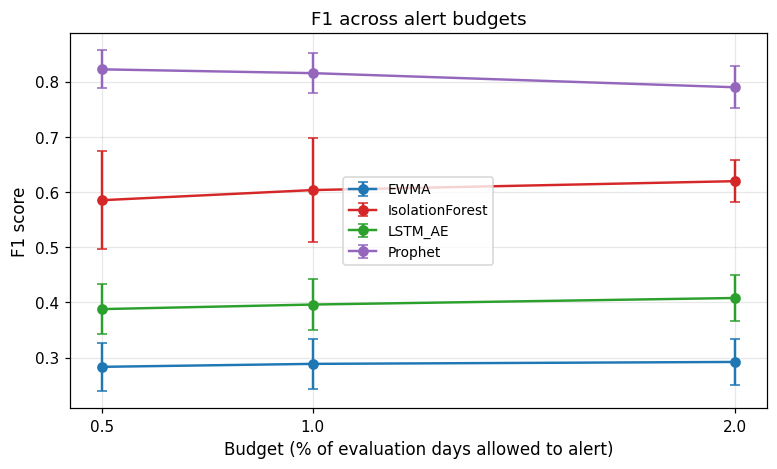

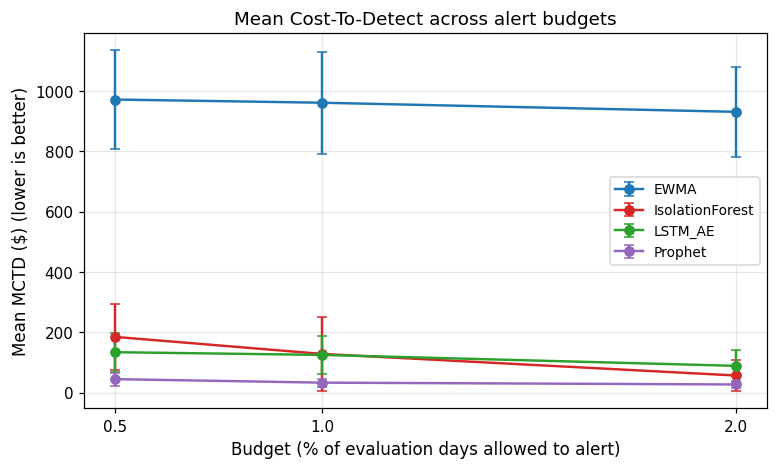

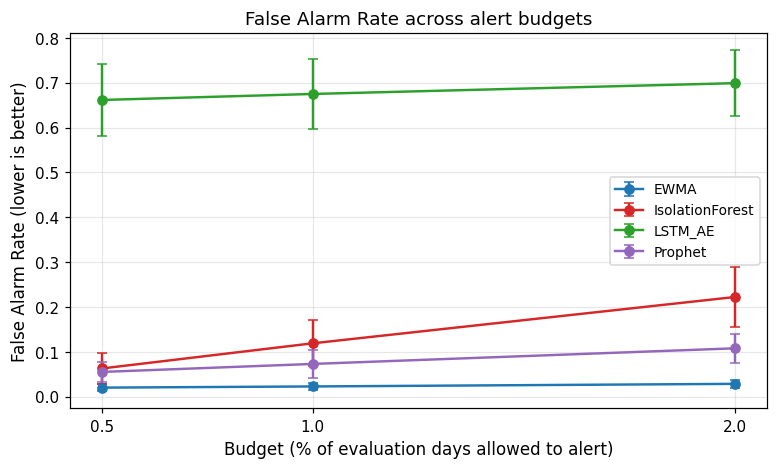

In [ ]:
def plot_paper_line(summary_df, metric, save_path,
                    ylabel=None, title=None,
                    lower_is_better=False):
    """
    budget축으로 metric 변화를 보는 paper-ready 선 그래프.

    - x : budget (% 단위)
    - y : metric mean, errorbar = std
    - 모델별 라인 (PAPER_COLOR_MAP 색상 고정)
    - lower_is_better=True면 y축 라벨에 명시
    """
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"

    # 모델 이름은 알파벳 정렬 (legend 가독성)
    for name in sorted(summary_df["model_name"].unique()):
        sub = (summary_df[summary_df["model_name"] == name]
               .sort_values("budget"))
        ax.errorbar(sub["budget"].values * 100.0,
                    sub[mean_col].values,
                    yerr=sub[std_col].fillna(0.0).values,
                    marker="o", capsize=3, lw=1.6,
                    label=name,
                    color=PAPER_COLOR_MAP.get(name, None))

    base_ylabel = ylabel or metric
    if lower_is_better:
        base_ylabel = f"{base_ylabel} (lower is better)"
    ax.set_xlabel("Budget (% of evaluation days allowed to alert)")
    ax.set_ylabel(base_ylabel)
    ax.set_title(title or f"{metric} across budgets (mean \u00b1 std)")

    # x ticks는 BUDGETS 정의 그대로
    ax.set_xticks([b * 100.0 for b, _ in BUDGETS])
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, loc="best")
    plt.tight_layout()
    fig.savefig(save_path, dpi=PAPER_DPI, bbox_inches="tight")
    return fig


# 4) F1 by budget
_ = plot_paper_line(
    summary_metrics_df, "f1",
    save_path=os.path.join(FIGS_DIR_NEW, "paper_f1_by_budget.png"),
    ylabel="F1 score",
    title="F1 across alert budgets",
    lower_is_better=False,
)
plt.show()

# 5) MCTD by budget (lower-is-better)
_ = plot_paper_line(
    summary_metrics_df, "mean_mctd",
    save_path=os.path.join(FIGS_DIR_NEW, "paper_mctd_by_budget.png"),
    ylabel="Mean MCTD ($)",
    title="Mean Cost-To-Detect across alert budgets",
    lower_is_better=True,
)
plt.show()

# 6) False alarm rate by budget (lower-is-better)
_ = plot_paper_line(
    summary_metrics_df, "false_alarm_rate",
    save_path=os.path.join(FIGS_DIR_NEW, "paper_far_by_budget.png"),
    ylabel="False Alarm Rate",
    title="False Alarm Rate across alert budgets",
    lower_is_better=True,
)
plt.show()

## 4) 저장 산출물 점검

In [ ]:
# 결과 csv (Part 5에서 새로 생성된 것 + Part 4 누적)
print("=== results dir ===", RESULTS_DIR)
for f in sorted(os.listdir(RESULTS_DIR)):
    p = os.path.join(RESULTS_DIR, f)
    print(f"  {f:50s}  {os.path.getsize(p):>10,} bytes")

# 논문 figure (paper_ prefix)
print("\n=== figures dir (paper_ prefix only) ===", FIGS_DIR_NEW)
for f in sorted(os.listdir(FIGS_DIR_NEW)):
    if f.startswith("paper_"):
        p = os.path.join(FIGS_DIR_NEW, f)
        print(f"  {f:50s}  {os.path.getsize(p):>10,} bytes")

=== results dir === /content/finops_benchmark/results
  all_event_results.csv                                  215,025 bytes
  all_model_metrics.csv                                   25,769 bytes
  paper_core_results_budget1pct.csv                          421 bytes
  paper_rank_comparison_budget1pct.csv                       293 bytes
  summary_metrics.csv                                      6,033 bytes

=== figures dir (paper_ prefix only) === /content/finops_benchmark/figures
  paper_ace_bar_budget1pct.png                            83,468 bytes
  paper_dollar_recall_bar_budget1pct.png                  78,407 bytes
  paper_f1_bar_budget1pct.png                             70,515 bytes
  paper_f1_by_budget.png                                  70,808 bytes
  paper_far_by_budget.png                                 89,841 bytes
  paper_mctd_by_budget.png                                88,850 bytes


## Sanity check

검증 항목
1. Year 1 구간에 anomaly가 없는지
2. Year 2 구간에 anomaly가 있는지
3. event_table 이벤트 구간이 서로 겹치지 않는지
4. anomaly 구간의 excess_cost가 양수인지
5. 정상 구간 excess_cost가 noise 수준인지 (설계상 0이 아니라 noise이므로 noise scale 비교)
6. seed별 event 개수 분포
7. 모델별 threshold가 Year 1 score만으로 계산됐는지
8. AUPRC가 raw score 기준으로 계산됐는지

PASS / FAIL / WARN / INFO 형태로 표 출력.

In [ ]:
def run_sanity_checks(df, events_df, scores_long, thresholds,
                      predictions_df, model_metrics_df,
                      all_model_metrics_df=None,
                      all_event_results_df=None,
                      year2_start=YEAR2_START,
                      noise_pct=NOISE_PCT):
    """
    Part 1~4 결과에 대한 검증을 수행하고 (요약표, 부속 상세 dict)를 반환한다.

    상태 코드
        PASS : 기대대로 통과
        WARN : 설계상 허용 가능한 편차이거나 회색 영역
        FAIL : 명백한 오류
        INFO : 단순 정보 (판정 없음)
    """
    rows = []
    detail_store = {}

    # ----------------------------------------------------------
    # Check 1. Year 1 has no anomalies
    # ----------------------------------------------------------
    n_y1 = int(df.loc[df["day"] < year2_start, "is_anomaly"].sum())
    rows.append({
        "id": 1,
        "check": "Year 1 has no anomalies",
        "status": "PASS" if n_y1 == 0 else "FAIL",
        "detail": f"Year 1 anomaly days = {n_y1} (expected 0)",
    })

    # ----------------------------------------------------------
    # Check 2. Year 2 has anomalies
    # ----------------------------------------------------------
    n_y2 = int(df.loc[df["day"] >= year2_start, "is_anomaly"].sum())
    rows.append({
        "id": 2,
        "check": "Year 2 has anomalies",
        "status": "PASS" if n_y2 > 0 else "FAIL",
        "detail": f"Year 2 anomaly days = {n_y2}",
    })

    # ----------------------------------------------------------
    # Check 3. Event intervals do not overlap
    #   start_day로 정렬한 뒤 인접 쌍의 (e_curr, s_next) 비교
    # ----------------------------------------------------------
    ev_sorted = events_df.sort_values("start_day").reset_index(drop=True)
    overlap_pairs = []
    for i in range(len(ev_sorted) - 1):
        e_curr = int(ev_sorted.loc[i, "end_day"])
        s_next = int(ev_sorted.loc[i + 1, "start_day"])
        if s_next <= e_curr:
            overlap_pairs.append((int(ev_sorted.loc[i, "event_id"]),
                                  int(ev_sorted.loc[i + 1, "event_id"])))
    rows.append({
        "id": 3,
        "check": "Event intervals do not overlap",
        "status": "PASS" if not overlap_pairs else "FAIL",
        "detail": (f"overlapping pairs = {overlap_pairs[:3]}"
                   f"{' (showing first 3)' if len(overlap_pairs) > 3 else ''}"),
    })

    # ---------------------------------------------------------
    # Check 4. cost_impact >= 0 in anomaly days
    #   ground-truth 주입 비용은 항상 >= 0이어야 한다.
    #   (이전 버전은 noise 포함 residual을 검증했으므로 1건 음수 발생 가능했음)
    # ---------------------------------------------------------
    anom_mask = df["is_anomaly"].astype(bool)
    n_anom = int(anom_mask.sum())
    if n_anom > 0:
        ci_anom = df.loc[anom_mask, "cost_impact"].values
        n_nonneg = int((ci_anom >= 0).sum())
        n_neg = int((ci_anom < 0).sum())
        n_pos = int((ci_anom > 0).sum())
        status = "PASS" if n_neg == 0 else "FAIL"
        rows.append({
            "id": 4,
            "check": "cost_impact >= 0 in anomaly days (ground truth)",
            "status": status,
            "detail": (f"non-negative ratio = {n_nonneg/n_anom:.4f} "
                      f"({n_nonneg}/{n_anom}), positive = {n_pos}, "
                      f"negative = {n_neg}"),
        })
    else:
        rows.append({"id": 4,
                    "check": "cost_impact >= 0 in anomaly days (ground truth)",
                    "status": "FAIL", "detail": "no anomaly days found"})

    # ---------------------------------------------------------
    # Check 5. Normal cost_impact == 0
    #   ground-truth 정의상 정상 구간 비용 영향은 정확히 0.
    #   (observed residual인 excess_cost는 noise 때문에 0이 아니지만,
    #    cost_impact는 주입량만 담으므로 0이어야 한다.)
    # ---------------------------------------------------------
    normal_mask = ~anom_mask
    ci_norm = df.loc[normal_mask, "cost_impact"].values
    n_normal = len(ci_norm)
    n_zero = int((ci_norm == 0).sum())
    status5 = "PASS" if n_zero == n_normal else "FAIL"
    rows.append({
        "id": 5,
        "check": "Normal cost_impact == 0 (ground truth)",
        "status": status5,
        "detail": (f"zero count = {n_zero}/{n_normal}, "
                  f"sum_abs = {float(np.sum(np.abs(ci_norm))):.6f}"),
    })

    # ----------------------------------------------------------
    # Check 6. Events per seed (multi-seed가 있으면 분포, 아니면 단일 seed 정보)
    # ----------------------------------------------------------
    if (all_event_results_df is not None
            and len(all_event_results_df) > 0
            and "seed" in all_event_results_df.columns):
        # 같은 seed 안에서는 모델/budget과 관계없이 event 수가 같아야 한다.
        first_budget = sorted(all_event_results_df["budget"].unique())[0]
        per_seed_model = (
            all_event_results_df[all_event_results_df["budget"] == first_budget]
            .groupby(["seed", "model_name"])["event_id"]
            .nunique()
            .unstack("model_name")
        )
        per_seed = per_seed_model.iloc[:, 0]                # 모델 0의 카운트
        all_models_match = per_seed_model.eq(per_seed, axis=0).all().all()
        n_min, n_max = int(per_seed.min()), int(per_seed.max())
        n_mean = float(per_seed.mean())
        n_std = float(per_seed.std())

        status6 = "PASS" if all_models_match else "FAIL"
        rows.append({
            "id": 6,
            "check": "Events per seed (consistent across models)",
            "status": status6,
            "detail": (f"n_seeds={len(per_seed)}, "
                       f"min={n_min}, max={n_max}, "
                       f"mean={n_mean:.1f}, std={n_std:.2f}, "
                       f"all-models-match={all_models_match}"),
        })
        detail_store["events_per_seed"] = per_seed_model
    else:
        rows.append({
            "id": 6,
            "check": "Events per seed (current single seed only)",
            "status": "INFO",
            "detail": f"n_events = {len(events_df)}",
        })

    # ----------------------------------------------------------
    # Check 7. Thresholds use Year 1 score only
    #   single-seed: thresholds dict와 compute_thresholds(Year1, 99%) 재계산값 비교
    #   추가: Year 2 99th percentile과 비교해 두 값이 같지 않은지도 확인
    # ----------------------------------------------------------
    recomputed = compute_thresholds(scores_long,
                                    year2_start=year2_start,
                                    percentile=99.0)
    diffs_y1 = {k: abs(thresholds[k] - recomputed[k]) for k in thresholds}
    max_diff_y1 = max(diffs_y1.values())

    # Year 2 99th percentile (확인용)
    y2_99 = {}
    for name, sub in scores_long.groupby("model_name"):
        s_y2 = sub.loc[sub["day"] >= year2_start, "score"].dropna().values
        y2_99[name] = float(np.percentile(s_y2, 99)) if len(s_y2) else float("nan")

    # 만약 thresholds == Year 2 99th 이면 학습 누수
    diffs_y2 = {k: abs(thresholds[k] - y2_99[k]) for k in thresholds}
    matches_y2 = all(d < 1e-9 for d in diffs_y2.values())

    status7 = "PASS" if (max_diff_y1 < 1e-9 and not matches_y2) else "FAIL"
    rows.append({
        "id": 7,
        "check": "Thresholds computed on Year 1 scores only",
        "status": status7,
        "detail": (f"max|saved - Year1 99th| = {max_diff_y1:.2e}, "
                   f"identical-to-Year2-99th = {matches_y2}"),
    })
    detail_store["threshold_diffs_year1"] = diffs_y1
    detail_store["threshold_diffs_year2"] = diffs_y2

    # ----------------------------------------------------------
    # Check 8. AUPRC uses raw score (not binary alert)
    #   model_metrics_df의 auprc와
    #     (a) raw score 기준 average_precision_score
    #     (b) binary alert 기준 average_precision_score
    #   두 가지를 모두 재계산해 어느 쪽과 일치하는지 본다.
    # ----------------------------------------------------------
    from sklearn.metrics import average_precision_score
    auprc_rows = []
    for name in model_metrics_df["model_name"]:
        sub = predictions_df[
            (predictions_df["model_name"] == name)
            & (predictions_df["day"] >= year2_start)
        ]
        y_true = sub["is_anomaly"].astype(int).values
        if y_true.sum() == 0:
            auprc_rows.append({
                "model": name, "saved": float("nan"),
                "recomp_score": float("nan"),
                "recomp_alert": float("nan"),
                "diff_score": float("nan"),
                "diff_alert": float("nan"),
            })
            continue
        y_score = sub["score"].fillna(0.0).values
        y_alert = sub["alert"].astype(int).values
        recomp_score = float(average_precision_score(y_true, y_score))
        recomp_alert = float(average_precision_score(y_true, y_alert))
        saved = float(model_metrics_df.loc[
            model_metrics_df["model_name"] == name, "auprc"
        ].iloc[0])
        auprc_rows.append({
            "model": name, "saved": saved,
            "recomp_score": recomp_score,
            "recomp_alert": recomp_alert,
            "diff_score": abs(saved - recomp_score),
            "diff_alert": abs(saved - recomp_alert),
        })
    auprc_df = pd.DataFrame(auprc_rows)
    max_d_score = float(np.nanmax(auprc_df["diff_score"]))
    max_d_alert = float(np.nanmax(auprc_df["diff_alert"]))
    status8 = "PASS" if max_d_score < 1e-9 else (
        "FAIL" if max_d_alert < 1e-9 else "WARN"
    )
    rows.append({
        "id": 8,
        "check": "AUPRC uses raw score (not binary alert)",
        "status": status8,
        "detail": (f"max|saved - score-based| = {max_d_score:.2e}, "
                   f"max|saved - alert-based| = {max_d_alert:.2e}"),
    })
    detail_store["auprc_table"] = auprc_df

    summary = pd.DataFrame(rows)[["id", "check", "status", "detail"]]
    return summary, detail_store


# ---- 실행 ----
sanity_summary, sanity_details = run_sanity_checks(
    df=df,
    events_df=events_df,
    scores_long=scores_long,
    thresholds=thresholds,
    predictions_df=predictions_df,
    model_metrics_df=model_metrics_df,
    all_model_metrics_df=all_model_metrics_df if "all_model_metrics_df" in dir() else None,
    all_event_results_df=all_event_results_df if "all_event_results_df" in dir() else None,
)

# 메인 요약표
print("=" * 88)
print("SANITY CHECK SUMMARY")
print("=" * 88)
# detail이 길어 wrap 되지 않도록 컬럼 폭을 충분히 잡고 출력
with pd.option_context("display.max_colwidth", 110):
    print(sanity_summary.to_string(index=False))

# AUPRC 상세표 (체크 8 보조)
print("\n" + "-" * 88)
print("AUPRC verification detail (Check 8)")
print("-" * 88)
print(sanity_details["auprc_table"].round(6).to_string(index=False))

# events per seed 분포 (체크 6 보조, 멀티시드일 때만)
if "events_per_seed" in sanity_details:
    print("\n" + "-" * 88)
    print("Events per seed x model (Check 6)")
    print("-" * 88)
    print(sanity_details["events_per_seed"].to_string())

# threshold 차이 (체크 7 보조)
print("\n" + "-" * 88)
print("Threshold diffs vs Year 1 99th (Check 7)")
print("-" * 88)
for k in sanity_details["threshold_diffs_year1"]:
    d1 = sanity_details["threshold_diffs_year1"][k]
    d2 = sanity_details["threshold_diffs_year2"][k]
    print(f"  {k:18s} |saved - Year1 99th| = {d1:.3e},  "
          f"|saved - Year2 99th| = {d2:.3e}")

SANITY CHECK SUMMARY
 id                                           check status                                                                   detail
  1                         Year 1 has no anomalies   PASS                                     Year 1 anomaly days = 0 (expected 0)
  2                            Year 2 has anomalies   PASS                                                Year 2 anomaly days = 108
  3                  Event intervals do not overlap   PASS                                                   overlapping pairs = []
  4 cost_impact >= 0 in anomaly days (ground truth)   PASS      non-negative ratio = 1.0000 (108/108), positive = 108, negative = 0
  5          Normal cost_impact == 0 (ground truth)   PASS                                 zero count = 622/622, sum_abs = 0.000000
  6      Events per seed (consistent across models)   PASS   n_seeds=10, min=28, max=34, mean=30.3, std=2.16, all-models-match=True
  7       Thresholds computed on Year 1 scores only   P